# Forecasting XAU-USD
In this model we will try to forecast XAU - USD close value

#### Install required packages

In [ ]:
!pip install skforecast yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.7/415.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 40.1 MB/s eta 0:00:00


#### Import dependencies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# For skforecast >= 0.14.0, use ForecasterRecursive instead of ForecasterAutoreg
try:
    from skforecast.recursive import ForecasterRecursive as ForecasterAutoreg
except ImportError:
    # Fallback for older versions
    from skforecast.ForecasterAutoreg import ForecasterAutoreg

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from skforecast.model_selection import backtesting_forecaster
import numpy as np
from skforecast.model_selection import grid_search_forecaster

# For skforecast >= 0.14.0, need TimeSeriesFold for grid search
try:
    from skforecast.model_selection import TimeSeriesFold
except ImportError:
    TimeSeriesFold = None

# Optional (Deep Learning with TensorFlow). If not installed, code will fall back to sklearn MLP.
try:
    import tensorflow as tf
    from tensorflow import keras
except Exception:
    tf = None
    keras = None

import yfinance as yf
from datetime import datetime, timedelta
import joblib
import os
import json
import warnings
import random
warnings.filterwarnings("ignore")

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
if tf is not None:
    tf.random.set_seed(SEED)


##### Load XAU-USD data using yfinance
We will download up-to-date data from yfinance. Data will be downloaded from 2004 to current date.

In [ ]:
# Download XAU-USD data from yfinance
# XAU-USD is the ticker for Gold vs USD
print("Downloading XAU-USD data from yfinance...")
ticker = "GC=F"  # Gold futures, or use "XAUUSD=X" for spot
start_date = "2009-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

# Download data
data = yf.download(ticker, start=start_date, end=end_date, interval="1d", progress=False)

# If GC=F doesn't work, try XAUUSD=X
if data.empty:
    print("Trying alternative ticker XAUUSD=X...")
    data = yf.download("XAUUSD=X", start=start_date, end=end_date, interval="1d", progress=False)

# Handle multi-level columns if present (yfinance sometimes returns MultiIndex)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# Ensure column names are simple strings (Open, High, Low, Close, Volume)
# Remove any spaces and convert to proper case
data.columns = [str(col).strip() for col in data.columns]
df = data.copy()

# Select only the columns we need
required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
available_cols = [col for col in required_cols if col in df.columns]
df = df[available_cols]

print(f"Data downloaded successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Data downloaded successfully!
Date range: 2009-01-02 00:00:00 to 2026-03-18 00:00:00
Total rows: 4327
Columns: ['Open', 'High', 'Low', 'Close', 'Volume']


,Open,High,Low,Close,Volume
Date,,,,,
2009-01-02,881.500000,881.500000,868.900024,878.799988,46
2009-01-05,882.000000,883.500000,847.000000,857.200012,35
2009-01-06,855.099976,867.599976,840.000000,865.400024,113
2009-01-07,862.000000,867.000000,837.700012,841.099976,101
2009-01-08,837.900024,861.000000,837.900024,853.900024,255


#### Formatting DataFrame



In [ ]:
# Data from yfinance already has Date as index
# Sort the data
df.sort_index(inplace = True)

# Set the dataset frequency to be (D)aily data
df = df.asfreq('D', method = 'bfill')

# Fill missing value with the latest available data
df.ffill(inplace = True)

# Ensure we have the required columns (Open, High, Low, Close, Volume)
print(f"Columns: {df.columns.tolist()}")
print(f"Data shape: {df.shape}")
df.head()

Columns: ['Open', 'High', 'Low', 'Close', 'Volume']
Data shape: (6285, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2009-01-02,881.500000,881.500000,868.900024,878.799988,46
2009-01-03,882.000000,883.500000,847.000000,857.200012,35
2009-01-04,882.000000,883.500000,847.000000,857.200012,35
2009-01-05,882.000000,883.500000,847.000000,857.200012,35
2009-01-06,855.099976,867.599976,840.000000,865.400024,113


In [ ]:
# Feature Engineering
# Create variation features
df['var_Prev_Open'] = df['Open'].shift(1) - df['Open'].shift(2)
df['var_Prev_Close'] = df['Close'].shift(1) - df['Close'].shift(2)
df['var_Prev_High'] = df['High'].shift(1) - df['High'].shift(2)
df['var_Prev_Low'] = df['Low'].shift(1) - df['Low'].shift(2)
if 'Volume' in df.columns:
    df['var_Prev_Volume'] = df['Volume'].shift(1) - df['Volume'].shift(2)
else:
    df['var_Prev_Volume'] = 0

# Target variable: change in Close price
df['var_Close'] = df['Close'] - df['Close'].shift(1)
df['prev_Close'] = df['Close'].shift(1)

# Create lagged variables for the features
print("Creating lagged variables...")
for lag in range(1, 31):  # Creating 30 lagged variables
    df[f'var_Prev_Close_lag_{lag}'] = df['var_Prev_Close'].shift(lag)
    df[f'var_Prev_Volume_{lag}'] = df['var_Prev_Volume'].shift(lag)
    df[f'var_Prev_High_{lag}'] = df['var_Prev_High'].shift(lag)
    df[f'var_Prev_Low_{lag}'] = df['var_Prev_Low'].shift(lag)
    df[f'var_Prev_Open_{lag}'] = df['var_Prev_Open'].shift(lag)

# Drop rows with NaN values (from shifting)
df.dropna(inplace=True)

print(f"Feature engineering completed!")
print(f"Data shape after feature engineering: {df.shape}")
print(f"Number of features: {len(df.columns)}")
df.head()

Creating lagged variables...
Feature engineering completed!
Data shape after feature engineering: (6253, 162)
Number of features: 162


,Open,High,Low,Close,Volume,var_Prev_Open,var_Prev_Close,var_Prev_High,var_Prev_Low,var_Prev_Volume,...,var_Prev_Close_lag_29,var_Prev_Volume_29,var_Prev_High_29,var_Prev_Low_29,var_Prev_Open_29,var_Prev_Close_lag_30,var_Prev_Volume_30,var_Prev_High_30,var_Prev_Low_30,var_Prev_Open_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-02-03,903.200012,913.299988,889.799988,892.000000,1451,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,-21.599976,-11.0,2.000000,-21.900024,0.500000
2009-02-04,900.099976,909.200012,897.000000,901.599976,465,-21.099976,-14.700012,-15.500000,-12.400024,-1769.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2009-02-05,906.299988,924.400024,904.400024,913.599976,770,-3.100037,9.599976,-4.099976,7.200012,-986.0,...,8.200012,78.0,-15.900024,-7.000000,-26.900024,0.000000,0.0,0.000000,0.000000,0.000000
2009-02-06,914.500000,918.500000,909.500000,913.900024,334,6.200012,12.000000,15.200012,7.400024,305.0,...,-24.300049,-12.0,-0.599976,-2.299988,6.900024,8.200012,78.0,-15.900024,-7.000000,-26.900024
2009-02-07,910.000000,911.000000,891.799988,892.400024,984,8.200012,0.300049,-5.900024,5.099976,-436.0,...,12.800049,154.0,-6.000000,0.200012,-24.099976,-24.300049,-12.0,-0.599976,-2.299988,6.900024


#### Train and test
We will establish the train and test date frames

In [ ]:
# Set train and test periods - using up-to-date dates
# Training: from 2023-01-01 to 30 days before today
# Testing: last 30 days
today = datetime.now()
test_end = today.strftime('%Y-%m-%d')
test_start = (today - timedelta(days=30)).strftime('%Y-%m-%d')
train_end = (today - timedelta(days=31)).strftime('%Y-%m-%d')
train_start = '2022-01-01'

# Adjust dates based on available data
data_start = df.index.min().strftime('%Y-%m-%d')
data_end = df.index.max().strftime('%Y-%m-%d')

# Ensure train_start is not before data_start
if train_start < data_start:
    train_start = data_start

# Ensure test_end is not after data_endSS
if test_end > data_end:
    test_end = data_end
    test_start = (pd.to_datetime(test_end) - timedelta(days=30)).strftime('%Y-%m-%d')
    train_end = (pd.to_datetime(test_start) - timedelta(days=1)).strftime('%Y-%m-%d')

print(f"Available data range: {data_start} to {data_end}")
print(f"Training period: {train_start} to {train_end}")
print(f"Testing period: {test_start} to {test_end}")
print(f"Training samples: {len(df.loc[train_start:train_end])}")
print(f"Testing samples: {len(df.loc[test_start:test_end])}")

Available data range: 2009-02-03 to 2026-03-18
Training period: 2022-01-01 to 2026-02-15
Testing period: 2026-02-16 to 2026-03-18
Training samples: 1507
Testing samples: 31


##### Plotting train and test

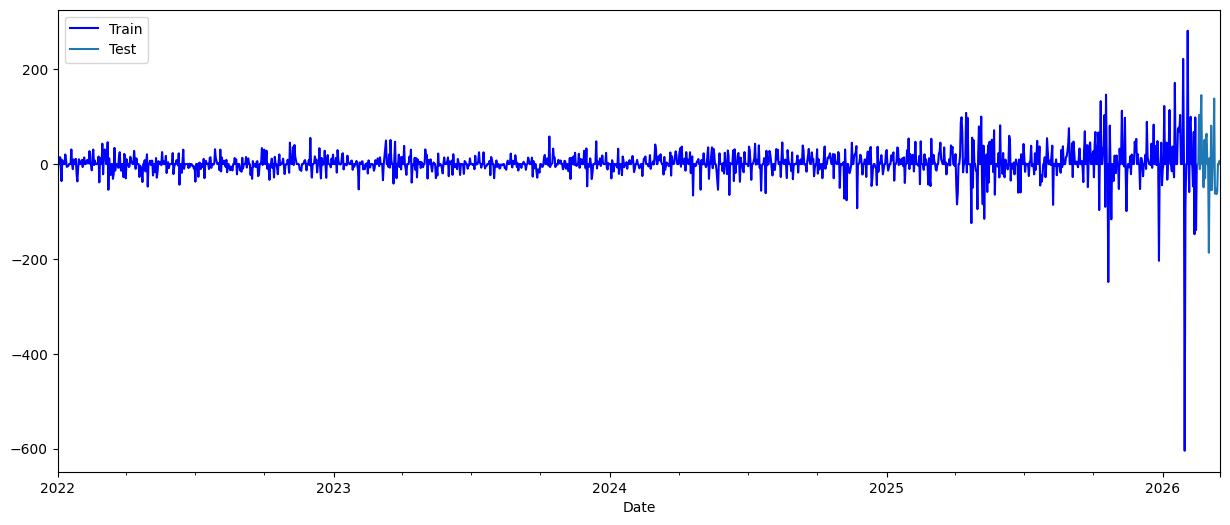

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
df.loc[train_start:train_end, 'var_Close'].plot(ax=ax, label="Train", color='blue')
df.loc[test_start:test_end, 'var_Close'].plot(ax=ax, label="Test")
ax.legend()

As we can see, we take the first years as train data and the last ones as test data
# Model
Ok, here we make our model, we will tune it before fitting it so we can minimize the error

In [ ]:
# Define the forecaster with multiple series
forecaster = ForecasterAutoreg(
    regressor = DecisionTreeRegressor(random_state = 123),
    lags = 30,
)

# Parameter Grid for Regressor
param_grid = {
    # max_depth: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    'max_depth' : [None, 1, 3, 5],
    # min_samples_split: The minimum number of samples required to split an internal node.
    'min_samples_split' : [2, 3, 4, 5, 6, 10],
    # ccp_alpha: Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen.
    'ccp_alpha' : [0.0, 0.001, 0.01]
}

# lags_grid: The number of previous observations to consider
lags_grid = [30, 50, 100, 150, [1,2,3,4,5,7,9,13,15,20,50], 10, 20]

print("Starting grid search... This may take a while...")

# Calculate test period length
test_steps = len(df.loc[test_start:test_end])
train_size = len(df.loc[train_start:train_end])

# For skforecast >= 0.14.0, use TimeSeriesFold
if TimeSeriesFold is not None:
    # Create TimeSeriesFold for cross-validation
    cv = TimeSeriesFold(
        steps = test_steps,
        initial_train_size = train_size,
        fixed_train_size = False,
        gap = 0,
        allow_incomplete_fold = True,
        refit = True
    )

    # Grid Search with TimeSeriesFold (new API)
    grid_forecaster = grid_search_forecaster(
        forecaster = forecaster,
        y = df.loc[train_start:test_end, 'var_Close'],
        exog = df.loc[train_start:test_end, df.columns.str.contains('var_Prev')],
        param_grid = param_grid,
        lags_grid = lags_grid,
        cv = cv,
        metric = 'mean_squared_error',
        return_best = True,
        verbose = False
    )
else:
    # Old API for versions < 0.14.0
    grid_forecaster = grid_search_forecaster(
        forecaster = forecaster,
        y = df.loc[train_start:test_end, 'var_Close'],
        exog = df.loc[train_start:test_end, df.columns.str.contains('var_Prev')],
        param_grid = param_grid,
        lags_grid = lags_grid,
        steps = test_steps,
        refit = True,
        metric = 'mean_squared_error',
        initial_train_size = train_size,
        fixed_train_size = False,
        return_best = True,
        verbose = False
    )

# Backtest RMSE
print(f"\nBest model RMSE: {np.sqrt(grid_forecaster.iloc[0]['mean_squared_error']):.4f}")
print(f"Best parameters: {grid_forecaster.iloc[0]}")
np.sqrt(grid_forecaster.iloc[0]['mean_squared_error'])


Starting grid search... This may take a while...


lags grid:   0%|          | 0/7 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

...

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]


Best model RMSE: 65.2919
Best parameters: lags                  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
lags_label            [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
params                {'ccp_alpha': 0.001, 'max_depth': 1, 'min_samp...
mean_squared_error                                          4263.036608
ccp_alpha                                                         0.001
max_depth                                                           1.0
min_samples_split                                                   3.0
Name: 0, dtype: object


np.float64(65.29193371357694)

#### Save Model
Save the trained model for future use

In [ ]:
# Save the trained model
model_filename = 'xau_usd_forecaster_model.pkl'
joblib.dump(forecaster, model_filename)
print(f"Model saved successfully as {model_filename}")

# Also save metadata
metadata = {
    'train_start': train_start,
    'train_end': train_end,
    'test_start': test_start,
    'test_end': test_end,
    'last_training_date': datetime.now().strftime('%Y-%m-%d')
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("Model metadata saved successfully")

Model saved successfully as xau_usd_forecaster_model.pkl
Model metadata saved successfully


#### Load Model
Load a previously saved model

In [ ]:
# Load the saved model (uncomment to use)
model_filename = 'xau_usd_forecaster_model.pkl'
if os.path.exists(model_filename):
    forecaster = joblib.load(model_filename)
    print(f"Model loaded successfully from {model_filename}")

    # Load metadata
    with open('model_metadata.json', 'r') as f:
        metadata = json.load(f)
    print("Model metadata loaded successfully")
else:
    print(f"Model file {model_filename} not found. Please train the model first.")

Model loaded successfully from xau_usd_forecaster_model.pkl
Model metadata loaded successfully


### Daily Prediction with Auto-Update
Get up-to-date prediction using latest data from yfinance

In [ ]:
print("🔮 DAILY GOLD PRICE PREDICTION")
print("="*50)
print("Auto-updating with latest data from yfinance...")
print("="*50)

# Check if model exists
if 'forecaster' not in globals() or forecaster is None:
    print(" No model found! Please train or load a model first.")
else:
    try:
        print(" Downloading latest data from yfinance...")

        # Get the feature column names used during training
        exog_columns = df.columns[df.columns.str.contains('var_Prev')].tolist()
        print(f"   Model expects {len(exog_columns)} features")

        # Try multiple gold symbols
        latest_data = None
        for symbol in ['GC=F', 'XAUUSD=X']:
            try:
                ticker = yf.Ticker(symbol)
                latest_data = ticker.history(period="5d", interval="1d")
                if len(latest_data) > 0:
                    print(f"    Data downloaded from {symbol}")
                    break
            except:
                continue

        if latest_data is None or len(latest_data) == 0:
            print("   yfinance failed, using last available data...")
            # Use last row from df
            current_price = df['Close'].iloc[-1]
            current_date = df.index[-1]

            # Get last features using the same column order as training
            last_features = df[exog_columns].iloc[-1:].values

        else:
            # Normalize timezone
            if latest_data.index.tz is not None:
                latest_data.index = latest_data.index.tz_localize(None)

            # Get current price
            current_price = latest_data['Close'].iloc[-1]
            current_date = latest_data.index[-1]

            print(f"   Current price: ${current_price:.2f}")
            print(f"   Current date: {current_date}")

            # Prepare latest data - append to existing df
            temp_df = latest_data.copy()
            # Handle multi-level columns if present
            if isinstance(temp_df.columns, pd.MultiIndex):
                temp_df.columns = [col[0] if isinstance(col, tuple) else col for col in temp_df.columns]
            temp_df.columns = [str(col).strip() for col in temp_df.columns]

            # Select only the columns we need
            required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
            available_cols = [col for col in required_cols if col in temp_df.columns]
            temp_df = temp_df[available_cols]

            # Combine with existing df (only base columns)
            base_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
            existing_base = df[base_cols].copy()
            combined_base = pd.concat([existing_base, temp_df])
            combined_base = combined_base[~combined_base.index.duplicated(keep='last')].sort_index()

            # Recalculate ALL features from scratch on combined data
            print("   Calculating features from latest data...")
            combined_df = combined_base.copy()

            # Create variation features
            combined_df['var_Prev_Open'] = combined_df['Open'].shift(1) - combined_df['Open'].shift(2)
            combined_df['var_Prev_Close'] = combined_df['Close'].shift(1) - combined_df['Close'].shift(2)
            combined_df['var_Prev_High'] = combined_df['High'].shift(1) - combined_df['High'].shift(2)
            combined_df['var_Prev_Low'] = combined_df['Low'].shift(1) - combined_df['Low'].shift(2)
            if 'Volume' in combined_df.columns:
                combined_df['var_Prev_Volume'] = combined_df['Volume'].shift(1) - combined_df['Volume'].shift(2)
            else:
                combined_df['var_Prev_Volume'] = 0

            # Create lagged variables
            for lag in range(1, 31):
                combined_df[f'var_Prev_Close_lag_{lag}'] = combined_df['var_Prev_Close'].shift(lag)
                combined_df[f'var_Prev_Volume_{lag}'] = combined_df['var_Prev_Volume'].shift(lag)
                combined_df[f'var_Prev_High_{lag}'] = combined_df['var_Prev_High'].shift(lag)
                combined_df[f'var_Prev_Low_{lag}'] = combined_df['var_Prev_Low'].shift(lag)
                combined_df[f'var_Prev_Open_{lag}'] = combined_df['var_Prev_Open'].shift(lag)

            # Get last row features - use the same column order as training
            last_features = combined_df[exog_columns].iloc[-1:].values

        # Handle NaN values
        if np.any(np.isnan(last_features)):
            print("  Some indicators have NaN, filling with 0...")
            last_features = np.nan_to_num(last_features, nan=0.0)

        # Get the last date from training data to determine correct exog start date
        last_training_date = df.index[-1]
        # Exog must start one step ahead of last_window
        exog_start_date = pd.to_datetime(last_training_date) + timedelta(days=1)

        # Create DataFrame with correct column names, order, and index
        # Use exog_start_date as index (one step ahead of last_window)
        exog_features = pd.DataFrame(last_features, columns=exog_columns, index=[exog_start_date])

        print(f"   Using exog data for date: {exog_start_date.strftime('%Y-%m-%d')}")

        # Predict next day variation
        predicted_variation = forecaster.predict(steps=1, exog=exog_features)[0]

        # Calculate predicted close
        predicted_close = current_price + predicted_variation
        price_change = predicted_variation
        price_change_pct = (price_change / current_price) * 100

        print(f"\n PREDICTION RESULTS:")
        print(f"   Current Price: ${current_price:.2f}")
        print(f"   Predicted Price: ${predicted_close:.2f}")
        print(f"   Expected Change: ${price_change:+.2f} ({price_change_pct:+.2f}%)")

        if price_change > 0:
            trend = " BULLISH (Price expected to rise)"
        else:
            trend = " BEARISH (Price expected to fall)"

        print(f"   Trend: {trend}")
        print(f"\n Run this cell daily for updated predictions!")

    except Exception as e:
        print(f" Prediction error: {e}")
        import traceback
        traceback.print_exc()
        print("   Please check your internet connection or model training.")

🔮 DAILY GOLD PRICE PREDICTION
Auto-updating with latest data from yfinance...
   Model expects 155 features
    Data downloaded from GC=F
   Current price: $4857.00
   Current date: 2026-03-18 00:00:00
   Calculating features from latest data...
   Using exog data for date: 2026-03-19

 PREDICTION RESULTS:
   Current Price: $4857.00
   Predicted Price: $4859.71
   Expected Change: $+2.71 (+0.06%)
   Trend:  BULLISH (Price expected to rise)

 Run this cell daily for updated predictions!


#### Model fitting
After finding the best model, it automatically optimize our base model with the best variables.

In [ ]:
# Fit the model using train data with multiple series
forecaster.fit(y = df.loc[train_start:train_end, 'var_Close'], exog = df.loc[train_start:train_end, df.columns.str.contains('var_Prev')])

#### Predicting test data

In [ ]:
# Predict the test period with multiple series
predicted_test = forecaster.predict(steps = len(df.loc[test_start:test_end]), exog = df.loc[test_start:test_end, df.columns.str.contains('var_Prev')])

### Daily Prediction with Auto-Update
Get up-to-date prediction using latest data from yfinance

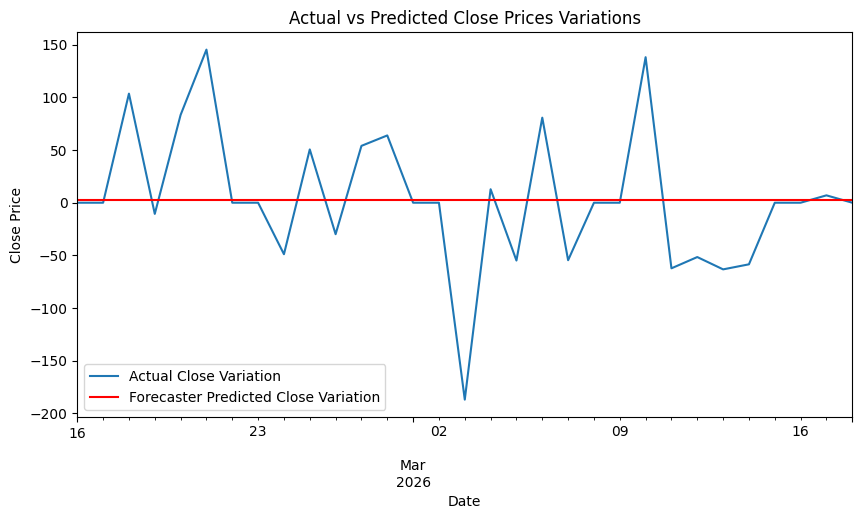

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
df.loc[test_start:test_end, 'var_Close'].plot(ax=ax, label = "Actual Close Variation")
predicted_test.plot(ax=ax, label='Forecaster Predicted Close Variation', color = 'red')
ax.set_title('Actual vs Predicted Close Prices Variations')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
ax.legend()
plt.show()

### Plotting actual Closes  versus Previous Close + Predicted closes Variations

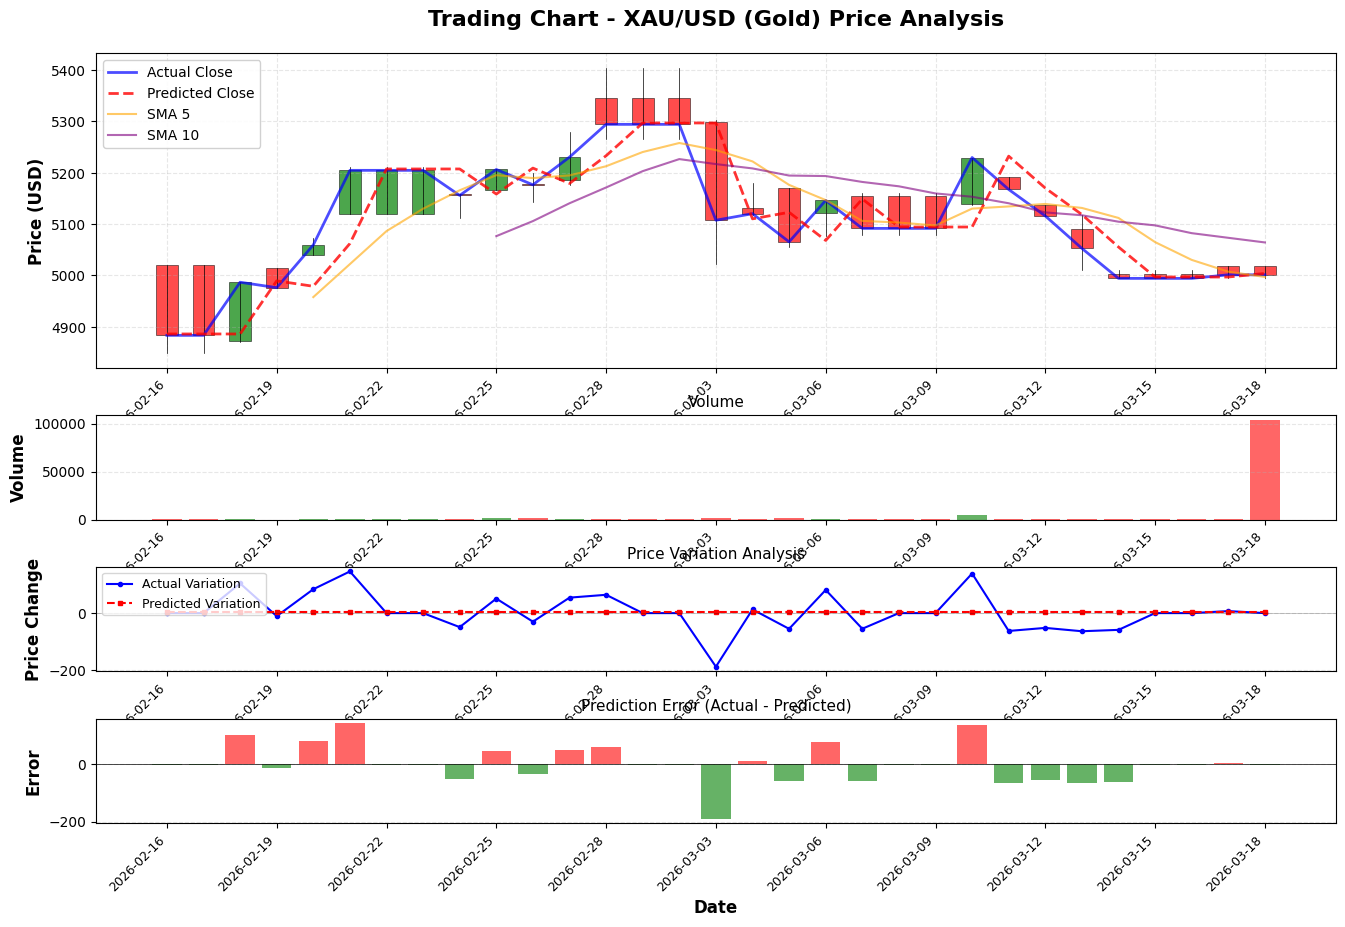


TRADING CHART STATISTICS
Period: 2026-02-16 to 2026-03-18
Total Trading Days: 31

Price Statistics:
  Actual Close - Min: $4882.90, Max: $5294.40
  Predicted Close - Min: $4885.59, Max: $5297.09

Prediction Accuracy:
  Mean Absolute Error: $44.87
  Root Mean Squared Error: $65.29
  Average Error: $1.12


In [ ]:
### Trading Chart Style - Detailed Analysis
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

# Prepare data
test_data = df.loc[test_start:test_end].copy()
pred_close = test_data['prev_Close'] + predicted_test

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.3)

# Main price chart with candlesticks
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0], sharex=ax1)

# Calculate moving averages
test_data['SMA_5'] = test_data['Close'].rolling(window=5).mean()
test_data['SMA_10'] = test_data['Close'].rolling(window=10).mean()

# Plot candlesticks
for idx, (date, row) in enumerate(test_data.iterrows()):
    open_price = row['Open']
    high_price = row['High']
    low_price = row['Low']
    close_price = row['Close']

    # Determine color
    color = 'green' if close_price >= open_price else 'red'

    # Draw wick
    ax1.plot([idx, idx], [low_price, high_price], color='black', linewidth=0.5)

    # Draw body
    body_height = abs(close_price - open_price)
    body_bottom = min(open_price, close_price)
    rect = Rectangle((idx-0.3, body_bottom), 0.6, body_height,
                     facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.7)
    ax1.add_patch(rect)

# Plot actual close line
ax1.plot(range(len(test_data)), test_data['Close'].values,
         label='Actual Close', color='blue', linewidth=2, alpha=0.7)

# Plot predicted close
ax1.plot(range(len(test_data)), pred_close.values,
         label='Predicted Close', color='red', linewidth=2, linestyle='--', alpha=0.8)

# Plot moving averages
ax1.plot(range(len(test_data)), test_data['SMA_5'].values,
         label='SMA 5', color='orange', linewidth=1.5, alpha=0.6)
ax1.plot(range(len(test_data)), test_data['SMA_10'].values,
         label='SMA 10', color='purple', linewidth=1.5, alpha=0.6)

# Format main chart
ax1.set_title('Trading Chart - XAU/USD (Gold) Price Analysis', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax1.set_xticks(range(len(test_data)))
ax1.set_xticklabels([date.strftime('%Y-%m-%d') for date in test_data.index], rotation=45, ha='right')

# Volume chart
if 'Volume' in test_data.columns:
    colors = ['green' if test_data['Close'].iloc[i] >= test_data['Open'].iloc[i]
              else 'red' for i in range(len(test_data))]
    ax2.bar(range(len(test_data)), test_data['Volume'].values,
            color=colors, alpha=0.6, width=0.8)
    ax2.set_ylabel('Volume', fontsize=12, fontweight='bold')
    ax2.set_title('Volume', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

# Price variation chart
ax3.plot(range(len(test_data)), test_data['var_Close'].values,
         label='Actual Variation', color='blue', linewidth=1.5, marker='o', markersize=3)
ax3.plot(range(len(test_data)), predicted_test.values,
         label='Predicted Variation', color='red', linewidth=1.5, marker='s', markersize=3, linestyle='--')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax3.set_ylabel('Price Change', fontsize=12, fontweight='bold')
ax3.set_title('Price Variation Analysis', fontsize=11)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# Error analysis chart
error = test_data['Close'].values - pred_close.values
ax4.bar(range(len(test_data)), error,
        color=['green' if e < 0 else 'red' for e in error], alpha=0.6, width=0.8)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_ylabel('Error', fontsize=12, fontweight='bold')
ax4.set_xlabel('Date', fontsize=12, fontweight='bold')
ax4.set_title('Prediction Error (Actual - Predicted)', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# Set x-axis labels for all subplots
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks(range(0, len(test_data), max(1, len(test_data)//10)))
    ax.set_xticklabels([test_data.index[i].strftime('%Y-%m-%d')
                        for i in range(0, len(test_data), max(1, len(test_data)//10))],
                       rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("TRADING CHART STATISTICS")
print("="*60)
print(f"Period: {test_start} to {test_end}")
print(f"Total Trading Days: {len(test_data)}")
print(f"\nPrice Statistics:")
print(f"  Actual Close - Min: ${test_data['Close'].min():.2f}, Max: ${test_data['Close'].max():.2f}")
print(f"  Predicted Close - Min: ${pred_close.min():.2f}, Max: ${pred_close.max():.2f}")
print(f"\nPrediction Accuracy:")
mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))
print(f"  Mean Absolute Error: ${mae:.2f}")
print(f"  Root Mean Squared Error: ${rmse:.2f}")
print(f"  Average Error: ${np.mean(error):.2f}")
print("="*60)


## Trading Strategy with Technical Indicators

This section adds technical indicators and trading signals based on RSI, MACD, Moving Averages, Bollinger Bands, and Stochastic Oscillator.

In [ ]:
# Install TA-Lib if not already installed
try:
    import talib
    print("✓ TA-Lib imported successfully")
except ImportError:
    print("⚠ TA-Lib not found. Installing...")
    import subprocess
    import sys
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "TA-Lib"],
                            stderr=subprocess.DEVNULL, stdout=subprocess.DEVNULL)
        import talib
        print("✓ TA-Lib installed and imported")
    except:
        print("✗ TA-Lib installation failed. Please install manually.")
        print("You can continue without TA-Lib, but technical indicators won't work.")
        talib = None

⚠ TA-Lib not found. Installing...
✓ TA-Lib installed and imported


In [ ]:
# Calculate Technical Indicators
print("Calculating Technical Indicators...")

# Prepare data for technical indicators
# Note: df already has Date as index (from yfinance)
price_data = df.copy()

# Extract OHLC data
close_prices = np.asarray(price_data['Close'].values, dtype=np.float64)
high_prices = np.asarray(price_data['High'].values, dtype=np.float64)
low_prices = np.asarray(price_data['Low'].values, dtype=np.float64)
open_prices = np.asarray(price_data['Open'].values, dtype=np.float64)

# Moving Averages
price_data['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
price_data['SMA_50'] = talib.SMA(close_prices, timeperiod=50)

# RSI (Relative Strength Index)
price_data['RSI'] = talib.RSI(close_prices, timeperiod=14)

# MACD (Moving Average Convergence Divergence)
macd, macdsignal, macdhist = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
price_data['MACD'] = macd
price_data['MACD_Signal'] = macdsignal
price_data['MACD_Hist'] = macdhist

# Bollinger Bands
upper_band, middle_band, lower_band = talib.BBANDS(close_prices, timeperiod=20, nbdevup=2, nbdevdn=2)
price_data['BB_Upper'] = upper_band
price_data['BB_Middle'] = middle_band
price_data['BB_Lower'] = lower_band

# Stochastic Oscillator
slowk, slowd = talib.STOCH(high_prices, low_prices, close_prices,
                          fastk_period=14, slowk_period=3, slowd_period=3)
price_data['Stoch_K'] = slowk
price_data['Stoch_D'] = slowd

print("✓ Technical indicators calculated successfully!")
print(f"Total features: {price_data.shape[1]}")
print("\nTechnical Indicators Summary (Last 10 days):")
print(price_data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'BB_Upper', 'BB_Lower', 'Stoch_K', 'Stoch_D']].tail(10))

Calculating Technical Indicators...
✓ Technical indicators calculated successfully!
Total features: 173

Technical Indicators Summary (Last 10 days):
                  Close       SMA_20       SMA_50        RSI       MACD  \
Date                                                                      
2026-03-09  5091.500000  5150.084985  5022.003994  50.131153  34.755506   
2026-03-10  5229.700195  5162.244995  5031.405996  58.901244  40.254561   
2026-03-11  5167.399902  5171.819995  5039.561992  54.268005  39.134371   
2026-03-12  5115.799805  5174.644995  5045.241992  50.710057  33.694507   
2026-03-13  5052.500000  5167.034985  5048.115996  46.667924  23.998965   
2026-03-14  4994.000000  5156.499976  5048.471992  43.237738  11.462584   
2026-03-15  4994.000000  5145.964966  5046.757988  43.237738   1.510005   
2026-03-16  4994.000000  5137.874976  5045.043984  43.237738  -6.304807   
2026-03-17  5001.000000  5127.604980  5043.469980  43.854490 -11.797270   
2026-03-18  5001.000000  

In [ ]:
# Generate trading signals based on technical indicators
def generate_signals(data):
    signals = pd.DataFrame(index=data.index)
    signals['Price'] = data['Close']

    # RSI Signals
    signals['RSI_Signal'] = 0
    signals.loc[data['RSI'] < 30, 'RSI_Signal'] = 1  # Oversold - Buy
    signals.loc[data['RSI'] > 70, 'RSI_Signal'] = -1  # Overbought - Sell

    # MACD Signals
    signals['MACD_Signal_Value'] = 0
    signals.loc[data['MACD'] > data['MACD_Signal'], 'MACD_Signal_Value'] = 1  # Bullish
    signals.loc[data['MACD'] < data['MACD_Signal'], 'MACD_Signal_Value'] = -1  # Bearish

    # Moving Average Crossover
    signals['MA_Signal'] = 0
    signals.loc[data['SMA_20'] > data['SMA_50'], 'MA_Signal'] = 1  # Golden Cross
    signals.loc[data['SMA_20'] < data['SMA_50'], 'MA_Signal'] = -1  # Death Cross

    # Bollinger Bands Signals
    signals['BB_Signal'] = 0
    signals.loc[data['Close'] < data['BB_Lower'], 'BB_Signal'] = 1  # Price below lower band - Buy
    signals.loc[data['Close'] > data['BB_Upper'], 'BB_Signal'] = -1  # Price above upper band - Sell

    # Stochastic Signals
    signals['Stoch_Signal'] = 0
    signals.loc[(data['Stoch_K'] < 20) & (data['Stoch_D'] < 20), 'Stoch_Signal'] = 1  # Oversold
    signals.loc[(data['Stoch_K'] > 80) & (data['Stoch_D'] > 80), 'Stoch_Signal'] = -1  # Overbought

    # Combined Signal (weighted)
    signals['Combined_Signal'] = (
        signals['RSI_Signal'] * 0.2 +
        signals['MACD_Signal_Value'] * 0.3 +
        signals['MA_Signal'] * 0.2 +
        signals['BB_Signal'] * 0.15 +
        signals['Stoch_Signal'] * 0.15
    )

    # Final Signal
    signals['Final_Signal'] = 0
    signals.loc[signals['Combined_Signal'] > 0.3, 'Final_Signal'] = 1  # Strong Buy
    signals.loc[signals['Combined_Signal'] < -0.3, 'Final_Signal'] = -1  # Strong Sell

    return signals

trading_signals = generate_signals(price_data)
print("Trading signals generated!")
print("\nSignal Summary (Last 20 days):")
print(trading_signals[['Price', 'RSI_Signal', 'MACD_Signal_Value', 'MA_Signal', 'Final_Signal']].tail(20))

Trading signals generated!

Signal Summary (Last 20 days):
                  Price  RSI_Signal  MACD_Signal_Value  MA_Signal  \
Date                                                                
2026-02-27  5230.500000           0                  1          1   
2026-02-28  5294.399902           0                  1          1   
2026-03-01  5294.399902           0                  1          1   
2026-03-02  5294.399902           0                  1          1   
2026-03-03  5107.399902           0                  1          1   
2026-03-04  5120.200195           0                 -1          1   
2026-03-05  5065.299805           0                 -1          1   
2026-03-06  5146.100098           0                 -1          1   
2026-03-07  5091.500000           0                 -1          1   
2026-03-08  5091.500000           0                 -1          1   
2026-03-09  5091.500000           0                 -1          1   
2026-03-10  5229.700195           0         

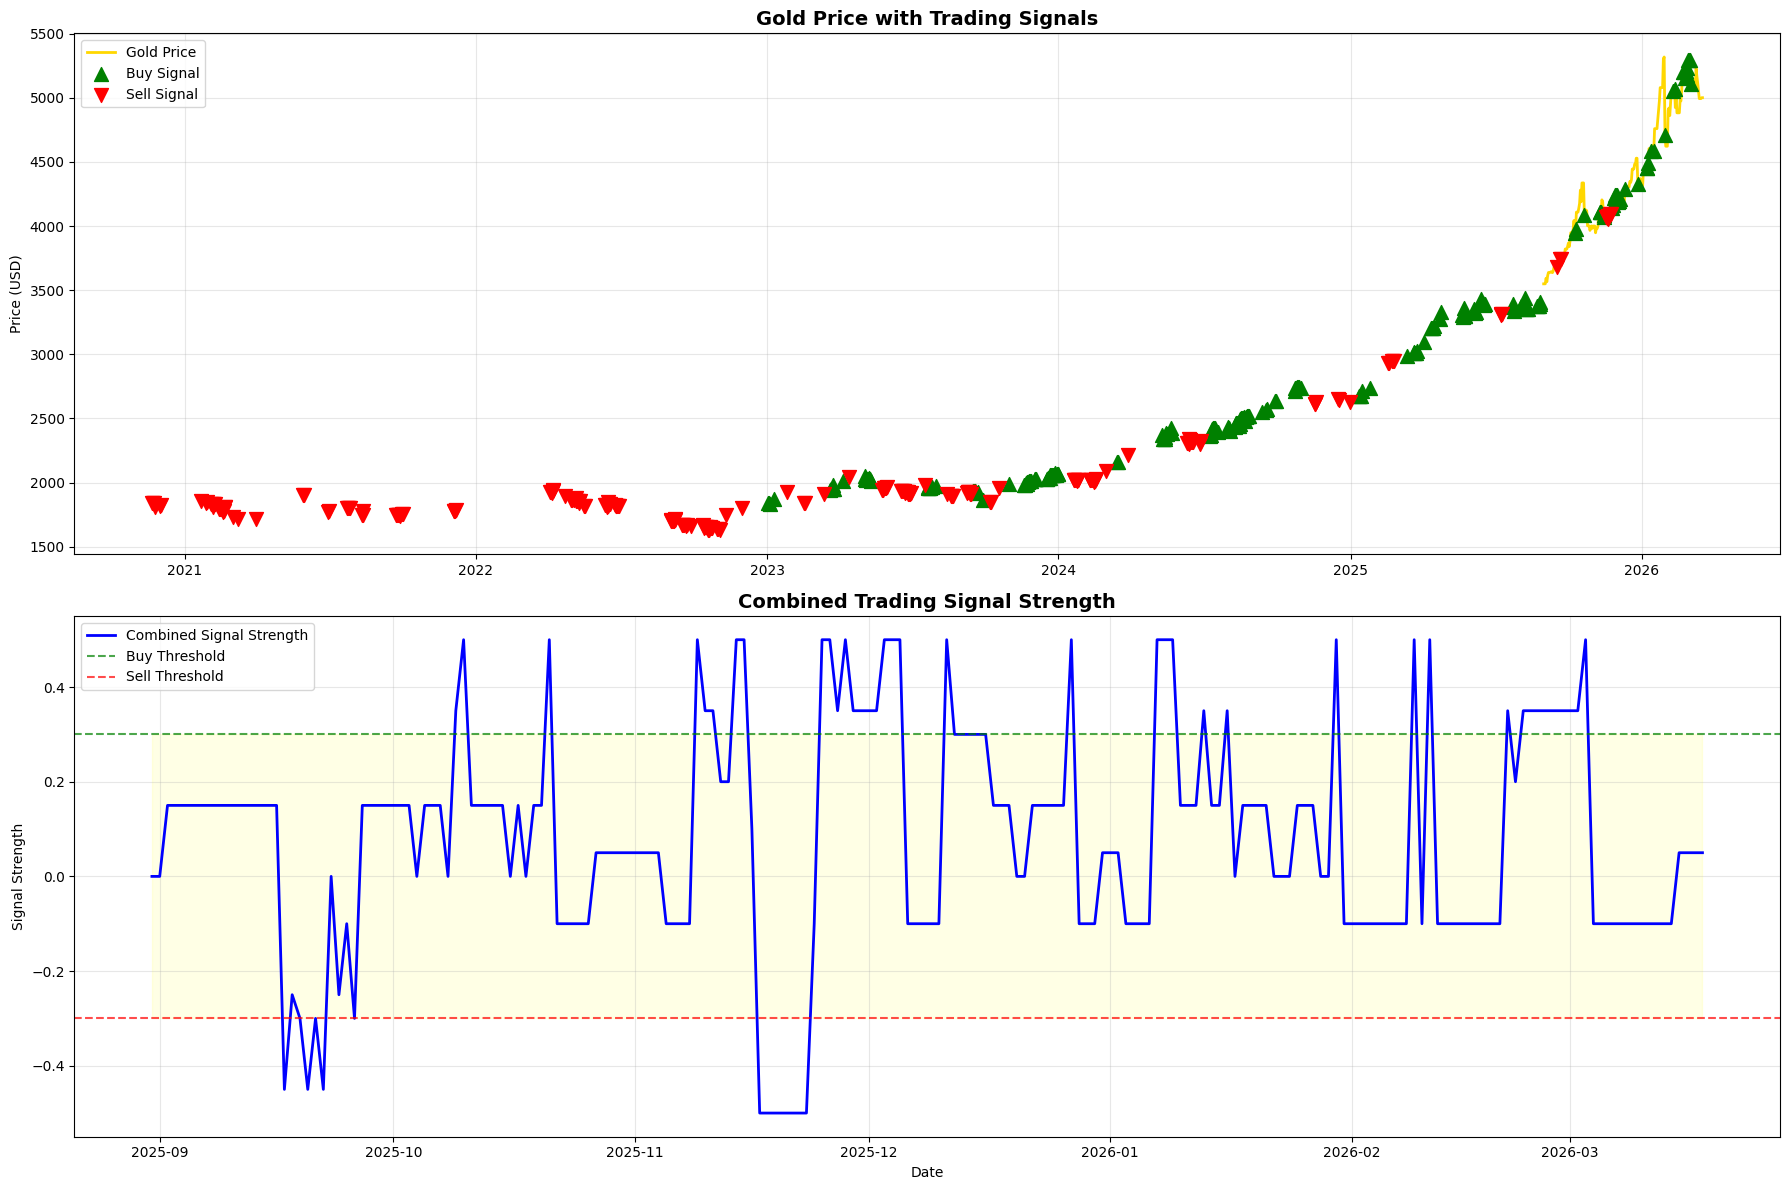

In [ ]:
# Visualize trading signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12))

# Price with signals
ax1.plot(trading_signals.index[-200:], trading_signals['Price'].iloc[-200:],
         label='Gold Price', color='gold', linewidth=2)
buy_signals = trading_signals[trading_signals['Final_Signal'] == 1]
sell_signals = trading_signals[trading_signals['Final_Signal'] == -1]

ax1.scatter(buy_signals.index[-200:], buy_signals['Price'].iloc[-200:],
           color='green', marker='^', s=100, label='Buy Signal', zorder=5)
ax1.scatter(sell_signals.index[-200:], sell_signals['Price'].iloc[-200:],
           color='red', marker='v', s=100, label='Sell Signal', zorder=5)
ax1.set_title('Gold Price with Trading Signals', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Combined signal strength
ax2.plot(trading_signals.index[-200:], trading_signals['Combined_Signal'].iloc[-200:],
         label='Combined Signal Strength', color='blue', linewidth=2)
ax2.axhline(y=0.3, color='g', linestyle='--', alpha=0.7, label='Buy Threshold')
ax2.axhline(y=-0.3, color='r', linestyle='--', alpha=0.7, label='Sell Threshold')
ax2.fill_between(trading_signals.index[-200:], -0.3, 0.3, alpha=0.1, color='yellow')
ax2.set_title('Combined Trading Signal Strength', fontsize=14, fontweight='bold')
ax2.set_ylabel('Signal Strength')
ax2.set_xlabel('Date')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Alternative Models (Random Forest & Deep Learning)
This section adds Random Forest (skforecast) and Deep Learning baseline (MLP / optional TensorFlow) for comparison.

## Model Comparison: OHLC vs Technical Indicators

This section compares prediction accuracy using:
1. OHLC data only
2. Technical indicators only  
3. Combined OHLC + Technical indicators

We'll test different ML models and timeframes to find the best combination for trading strategy.

In [ ]:
# Prepare datasets for comparison
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Prepare data with technical indicators
price_data_with_indicators = price_data.copy()
price_data_with_indicators = price_data_with_indicators.dropna()

# Prepare OHLC only dataset
ohlc_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
ohlc_data = ohlc_data.dropna()

# Prepare indicators only dataset (without OHLC)
indicators_only = price_data_with_indicators[['SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal',
                                              'BB_Upper', 'BB_Lower', 'Stoch_K', 'Stoch_D']].copy()
indicators_only = indicators_only.dropna()

# Prepare combined dataset (OHLC + Indicators)
combined_data = price_data_with_indicators[['Open', 'High', 'Low', 'Close', 'Volume',
                                            'SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal',
                                            'BB_Upper', 'BB_Lower', 'Stoch_K', 'Stoch_D']].copy()
combined_data = combined_data.dropna()

print("Dataset prepared:")
print(f"OHLC only shape: {ohlc_data.shape}")
print(f"Indicators only shape: {indicators_only.shape}")
print(f"Combined shape: {combined_data.shape}")

Dataset prepared:
OHLC only shape: (6253, 5)
Indicators only shape: (6204, 9)
Combined shape: (6204, 14)


In [ ]:
# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, dataset_name):
    """Train and evaluate a model, return metrics"""
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
        'model_name': model_name,
        'dataset_name': dataset_name,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'model': model,
        'scaler': scaler
    }

# Function to prepare data for different timeframes
def prepare_timeframe_data(data, target_col='Close', timeframe_days=1):
    """Prepare data with different prediction timeframes"""
    X = data.drop(columns=[target_col]).values
    y = data[target_col].shift(-timeframe_days).values  # Predict N days ahead

    # Remove NaN values
    valid_idx = ~np.isnan(y)
    X = X[valid_idx]
    y = y[valid_idx]

    return X, y

print("Evaluation functions prepared!")

Evaluation functions prepared!


In [ ]:
# Test different models and datasets
results = []

# Define models to test
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Define datasets
datasets = {
    'OHLC Only': (ohlc_data, ['Open', 'High', 'Low', 'Volume']),
    'Indicators Only': (price_data_with_indicators, ['SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal',
                                                      'BB_Upper', 'BB_Lower', 'Stoch_K', 'Stoch_D']),
    'Combined': (combined_data, ['Open', 'High', 'Low', 'Volume', 'SMA_20', 'SMA_50', 'RSI',
                                 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'Stoch_K', 'Stoch_D'])
}

# Test with 1-day ahead prediction
timeframe = 1
print(f"Testing models with {timeframe}-day ahead prediction...\n")

for dataset_name, (data, feature_cols) in datasets.items():
    # Prepare features and target
    X, y = prepare_timeframe_data(data[feature_cols + ['Close']], timeframe_days=timeframe)

    # Split data (80% train, 20% test)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    for model_name, model in models.items():
        result = evaluate_model(model, X_train, X_test, y_train, y_test,
                                model_name, f"{dataset_name} ({timeframe}D)")
        results.append(result)

        print(f"{model_name} - {dataset_name}:")
        print(f"  Test MAE: ${result['test_mae']:.2f}")
        print(f"  Test RMSE: ${result['test_rmse']:.2f}")
        print(f"  Test R²: {result['test_r2']:.4f}\n")

# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)
print(results_df[['model_name', 'dataset_name', 'test_mae', 'test_rmse', 'test_r2']].to_string(index=False))

Testing models with 1-day ahead prediction...

Linear Regression - OHLC Only:
  Test MAE: $20.01
  Test RMSE: $38.73
  Test R²: 0.9981

Random Forest - OHLC Only:
  Test MAE: $721.25
  Test RMSE: $1124.57
  Test R²: -0.5677

Gradient Boosting - OHLC Only:
  Test MAE: $715.85
  Test RMSE: $1119.79
  Test R²: -0.5544

Linear Regression - Indicators Only:
  Test MAE: $23.83
  Test RMSE: $43.33
  Test R²: 0.9977

Random Forest - Indicators Only:
  Test MAE: $761.00
  Test RMSE: $1155.99
  Test R²: -0.6611

Gradient Boosting - Indicators Only:
  Test MAE: $766.33
  Test RMSE: $1166.90
  Test R²: -0.6926

Linear Regression - Combined:
  Test MAE: $20.37
  Test RMSE: $38.36
  Test R²: 0.9982

Random Forest - Combined:
  Test MAE: $751.25
  Test RMSE: $1150.03
  Test R²: -0.6440

Gradient Boosting - Combined:
  Test MAE: $764.11
  Test RMSE: $1171.32
  Test R²: -0.7054


SUMMARY OF RESULTS
       model_name         dataset_name   test_mae   test_rmse   test_r2
Linear Regression       OHLC Only

In [ ]:
# Test with different timeframes (1-day, 3-day, 7-day ahead)
timeframes = [1, 3, 7]
timeframe_results = []

print("Testing different prediction timeframes with best model...\n")

# Use best model from previous test (Random Forest with Combined data)
best_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
combined_features = ['Open', 'High', 'Low', 'Volume', 'SMA_20', 'SMA_50', 'RSI',
                     'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'Stoch_K', 'Stoch_D']

for timeframe in timeframes:
    X, y = prepare_timeframe_data(combined_data[combined_features + ['Close']],
                                  timeframe_days=timeframe)

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Create new model instance for each timeframe to avoid conflicts
    model_for_timeframe = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    result = evaluate_model(model_for_timeframe, X_train, X_test, y_train, y_test,
                            'Random Forest', f'Combined ({timeframe}D)')
    timeframe_results.append(result)

    print(f"{timeframe}-day ahead prediction:")
    print(f"  Test MAE: ${result['test_mae']:.2f}")
    print(f"  Test RMSE: ${result['test_rmse']:.2f}")
    print(f"  Test R²: {result['test_r2']:.4f}\n")

timeframe_df = pd.DataFrame(timeframe_results)
print("="*80)
print("TIMEFRAME COMPARISON")
print("="*80)
print(timeframe_df[['dataset_name', 'test_mae', 'test_rmse', 'test_r2']].to_string(index=False))

Testing different prediction timeframes with best model...

1-day ahead prediction:
  Test MAE: $751.25
  Test RMSE: $1150.03
  Test R²: -0.6440

3-day ahead prediction:
  Test MAE: $768.39
  Test RMSE: $1162.37
  Test R²: -0.6794

7-day ahead prediction:
  Test MAE: $809.11
  Test RMSE: $1197.08
  Test R²: -0.7817

TIMEFRAME COMPARISON
 dataset_name   test_mae   test_rmse   test_r2
Combined (1D) 751.251941 1150.031762 -0.643987
Combined (3D) 768.392384 1162.367402 -0.679444
Combined (7D) 809.114094 1197.079595 -0.781738


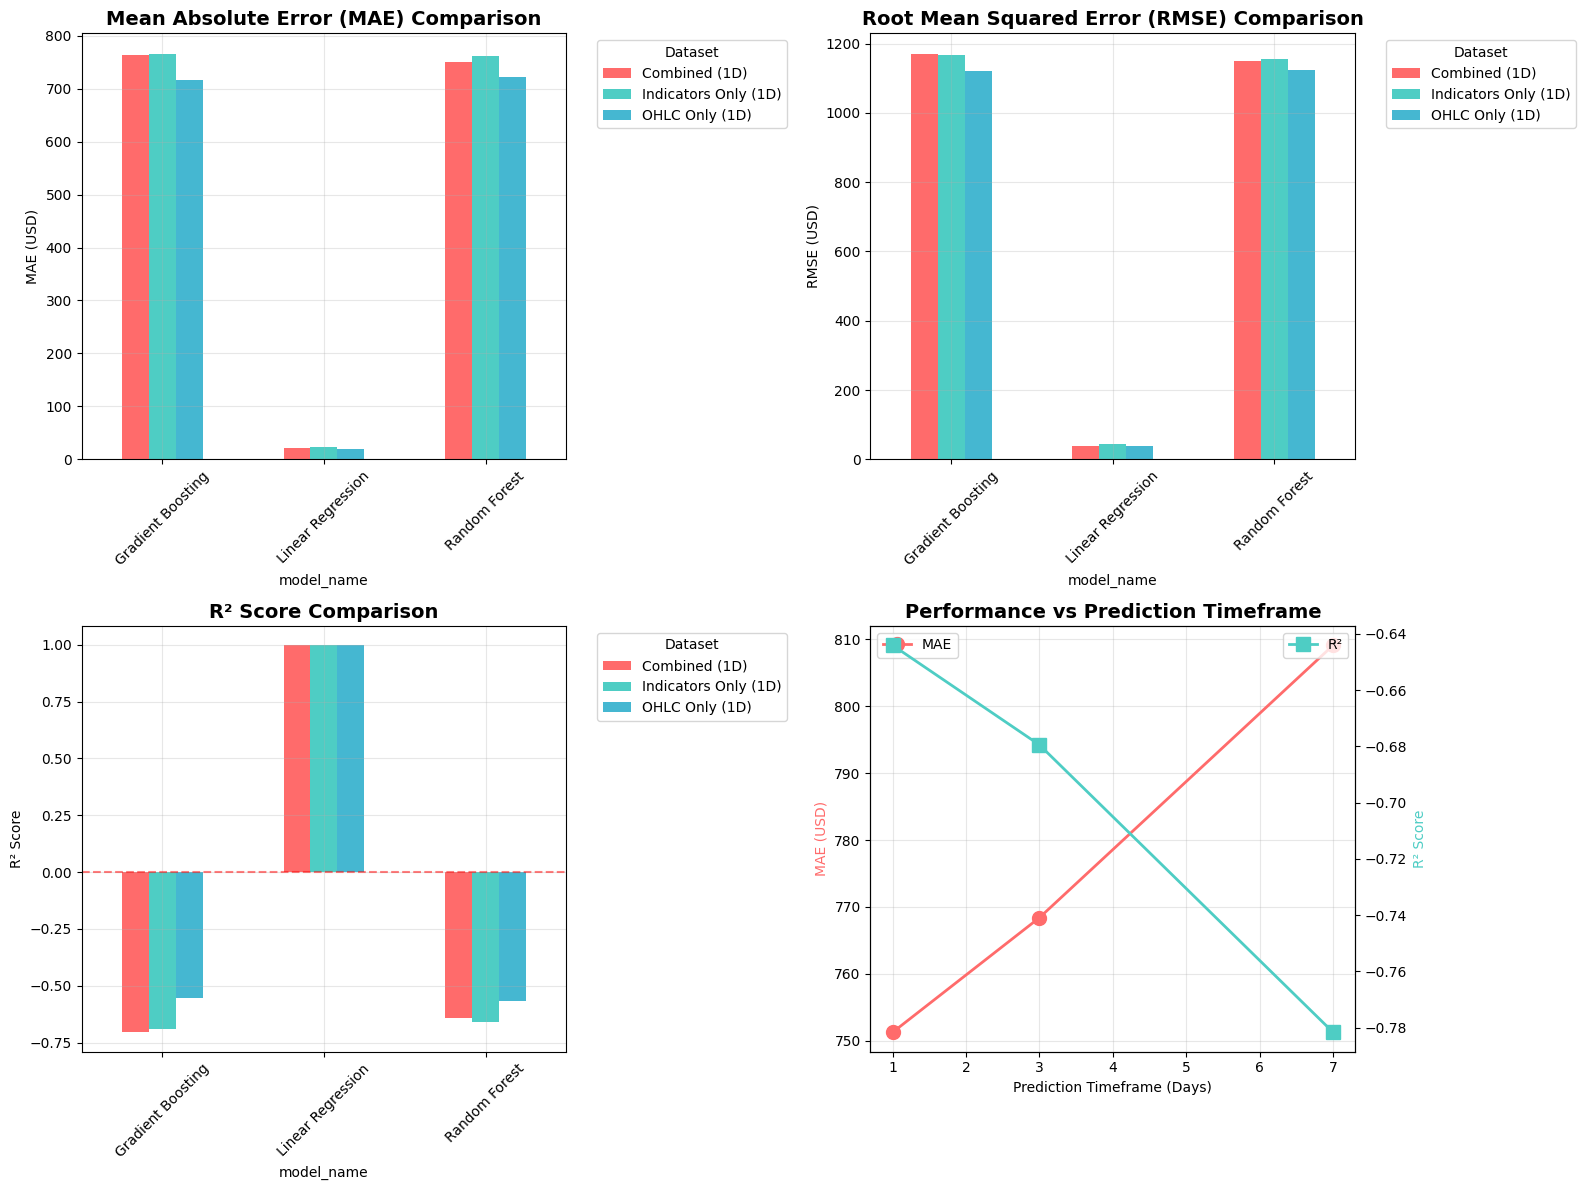

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. MAE Comparison
ax1 = axes[0, 0]
mae_data = results_df.pivot(index='model_name', columns='dataset_name', values='test_mae')
mae_data.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_title('Mean Absolute Error (MAE) Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('MAE (USD)')
ax1.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. RMSE Comparison
ax2 = axes[0, 1]
rmse_data = results_df.pivot(index='model_name', columns='dataset_name', values='test_rmse')
rmse_data.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_title('Root Mean Squared Error (RMSE) Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('RMSE (USD)')
ax2.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. R² Comparison
ax3 = axes[1, 0]
r2_data = results_df.pivot(index='model_name', columns='dataset_name', values='test_r2')
r2_data.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax3.set_title('R² Score Comparison', fontsize=14, fontweight='bold')
ax3.set_ylabel('R² Score')
ax3.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 4. Timeframe Comparison
ax4 = axes[1, 1]
timeframe_df['days'] = timeframe_df['dataset_name'].str.extract(r'\((\d+)D\)').astype(int)
ax4.plot(timeframe_df['days'], timeframe_df['test_mae'], marker='o', linewidth=2,
         markersize=10, label='MAE', color='#FF6B6B')
ax4_twin = ax4.twinx()
ax4_twin.plot(timeframe_df['days'], timeframe_df['test_r2'], marker='s', linewidth=2,
              markersize=10, label='R²', color='#4ECDC4')
ax4.set_xlabel('Prediction Timeframe (Days)')
ax4.set_ylabel('MAE (USD)', color='#FF6B6B')
ax4_twin.set_ylabel('R² Score', color='#4ECDC4')
ax4.set_title('Performance vs Prediction Timeframe', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Try additional advanced models
try:
    from xgboost import XGBRegressor
    from sklearn.neural_network import MLPRegressor
    xgboost_available = True
except ImportError:
    print("XGBoost not available, skipping...")
    xgboost_available = False

# Advanced models
advanced_models = {
    'Random Forest (200 trees)': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting (200 trees)': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'MLP Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

if xgboost_available:
    advanced_models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Testing advanced models with Combined dataset (1-day ahead)...\n")

advanced_results = []
X, y = prepare_timeframe_data(combined_data[combined_features + ['Close']], timeframe_days=1)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

for model_name, model in advanced_models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test,
                            model_name, 'Combined (1D)')
    advanced_results.append(result)

    print(f"{model_name}:")
    print(f"  Test MAE: ${result['test_mae']:.2f}")
    print(f"  Test RMSE: ${result['test_rmse']:.2f}")
    print(f"  Test R²: {result['test_r2']:.4f}\n")

advanced_df = pd.DataFrame(advanced_results)
print("="*80)
print("ADVANCED MODELS COMPARISON")
print("="*80)
print(advanced_df[['model_name', 'test_mae', 'test_rmse', 'test_r2']].to_string(index=False))

Testing advanced models with Combined dataset (1-day ahead)...

Random Forest (200 trees):
  Test MAE: $752.19
  Test RMSE: $1151.26
  Test R²: -0.6475

Gradient Boosting (200 trees):
  Test MAE: $775.86
  Test RMSE: $1181.50
  Test R²: -0.7352

MLP Neural Network:
  Test MAE: $20.73
  Test RMSE: $41.01
  Test R²: 0.9979

XGBoost:
  Test MAE: $762.52
  Test RMSE: $1161.20
  Test R²: -0.6761

ADVANCED MODELS COMPARISON
                   model_name   test_mae   test_rmse   test_r2
    Random Forest (200 trees) 752.187149 1151.258287 -0.647496
Gradient Boosting (200 trees) 775.858250 1181.504600 -0.735200
           MLP Neural Network  20.729168   41.011198  0.997909
                      XGBoost 762.515589 1161.197963 -0.676067


## Prediction Visualization

Visualize model predictions vs actual prices to see how well each model performs.

In [ ]:
# Function to generate predictions for visualization
from sklearn.base import clone

def generate_predictions_for_plot(
    model_result,
    data,
    feature_cols,
    timeframe_days=1,
    last_n_days=100,
    retrain_scaler=True,
    retrain_model_on_mismatch=True
):
    """Generate predictions for the last N days for visualization.

    Uses the stored scaler+model when feature counts match.
    If feature count mismatches (common when mixing OHLC vs Combined), it can
    retrain a fresh scaler+model on the correct feature set ONLY for plotting.
    """

    available_features = [f for f in feature_cols if f in data.columns]
    if len(available_features) != len(feature_cols):
        print(f"Warning: Some features missing. Expected {len(feature_cols)}, got {len(available_features)}")

    X, y = prepare_timeframe_data(data[available_features + ['Close']], timeframe_days=timeframe_days)

    X_plot = X[-last_n_days:]
    y_actual = y[-last_n_days:]

    # align dates with shifted y
    if timeframe_days > 0:
        dates = data.index[-(last_n_days + timeframe_days):-(timeframe_days)]
    else:
        dates = data.index[-last_n_days:]

    scaler = model_result.get('scaler', None)
    model = model_result.get('model', None)

    if model is None:
        raise ValueError("model_result does not contain a trained model.")

    # Check feature mismatch - check both scaler and model
    expected_features_scaler = None
    expected_features_model = None

    if scaler is not None and hasattr(scaler, 'n_features_in_'):
        expected_features_scaler = scaler.n_features_in_

    if model is not None and hasattr(model, 'n_features_in_'):
        expected_features_model = model.n_features_in_

    # Use model's expected features as primary check (more reliable)
    expected_features = expected_features_model or expected_features_scaler
    actual_features = X_plot.shape[1]

    # Check if mismatch
    needs_retrain = False
    if expected_features is not None and actual_features != expected_features:
        needs_retrain = True
    elif expected_features is None:
        # If we can't determine expected features, try to use original scaler/model
        # but if it fails, we'll retrain
        needs_retrain = False

    if needs_retrain:
        if not retrain_scaler or not retrain_model_on_mismatch:
            raise ValueError(
                f"Feature mismatch: X has {actual_features} features but model expects {expected_features}. "
                "Use matching model_result/dataset, or enable retrain_scaler and retrain_model_on_mismatch."
            )

        # Retrain for plotting
        print(f"Warning: Feature mismatch detected ({actual_features} vs {expected_features}). Retraining model for plotting...")
        scaler_new = StandardScaler()
        split_idx = int(len(X) * 0.8)
        X_train, y_train = X[:split_idx], y[:split_idx]

        X_train_scaled = scaler_new.fit_transform(X_train)
        model_new = clone(model)
        model_new.fit(X_train_scaled, y_train)

        X_plot_scaled = scaler_new.transform(X_plot)
        y_pred = model_new.predict(X_plot_scaled)
        return dates, y_actual, y_pred

    # Normal path - use existing scaler and model
    if scaler is None:
        scaler = StandardScaler().fit(X)

    try:
        X_plot_scaled = scaler.transform(X_plot)
        y_pred = model.predict(X_plot_scaled)
    except (ValueError, AttributeError) as e:
        # If prediction fails (likely feature mismatch), retrain
        print(f"Warning: Prediction failed ({str(e)}). Retraining model for plotting...")
        scaler_new = StandardScaler()
        split_idx = int(len(X) * 0.8)
        X_train, y_train = X[:split_idx], y[:split_idx]
        X_train_scaled = scaler_new.fit_transform(X_train)
        model_new = clone(model)
        model_new.fit(X_train_scaled, y_train)
        X_plot_scaled = scaler_new.transform(X_plot)
        y_pred = model_new.predict(X_plot_scaled)

    return dates, y_actual, y_pred

# Get predictions from best models
print("Generating predictions for visualization...\n")

best_combined = results_df[results_df['dataset_name'].str.contains('Combined')].loc[
    results_df[results_df['dataset_name'].str.contains('Combined')]['test_r2'].idxmax()
]

dates_1d, actual_1d, pred_1d = generate_predictions_for_plot(
    best_combined, combined_data, combined_features, timeframe_days=1, last_n_days=100
)

print(f"Using model: {best_combined['model_name']}")
print(f"Dataset: {best_combined['dataset_name']}")
print(f"R² Score: {best_combined['test_r2']:.4f}")

Generating predictions for visualization...

Using model: Linear Regression
Dataset: Combined (1D)
R² Score: 0.9982


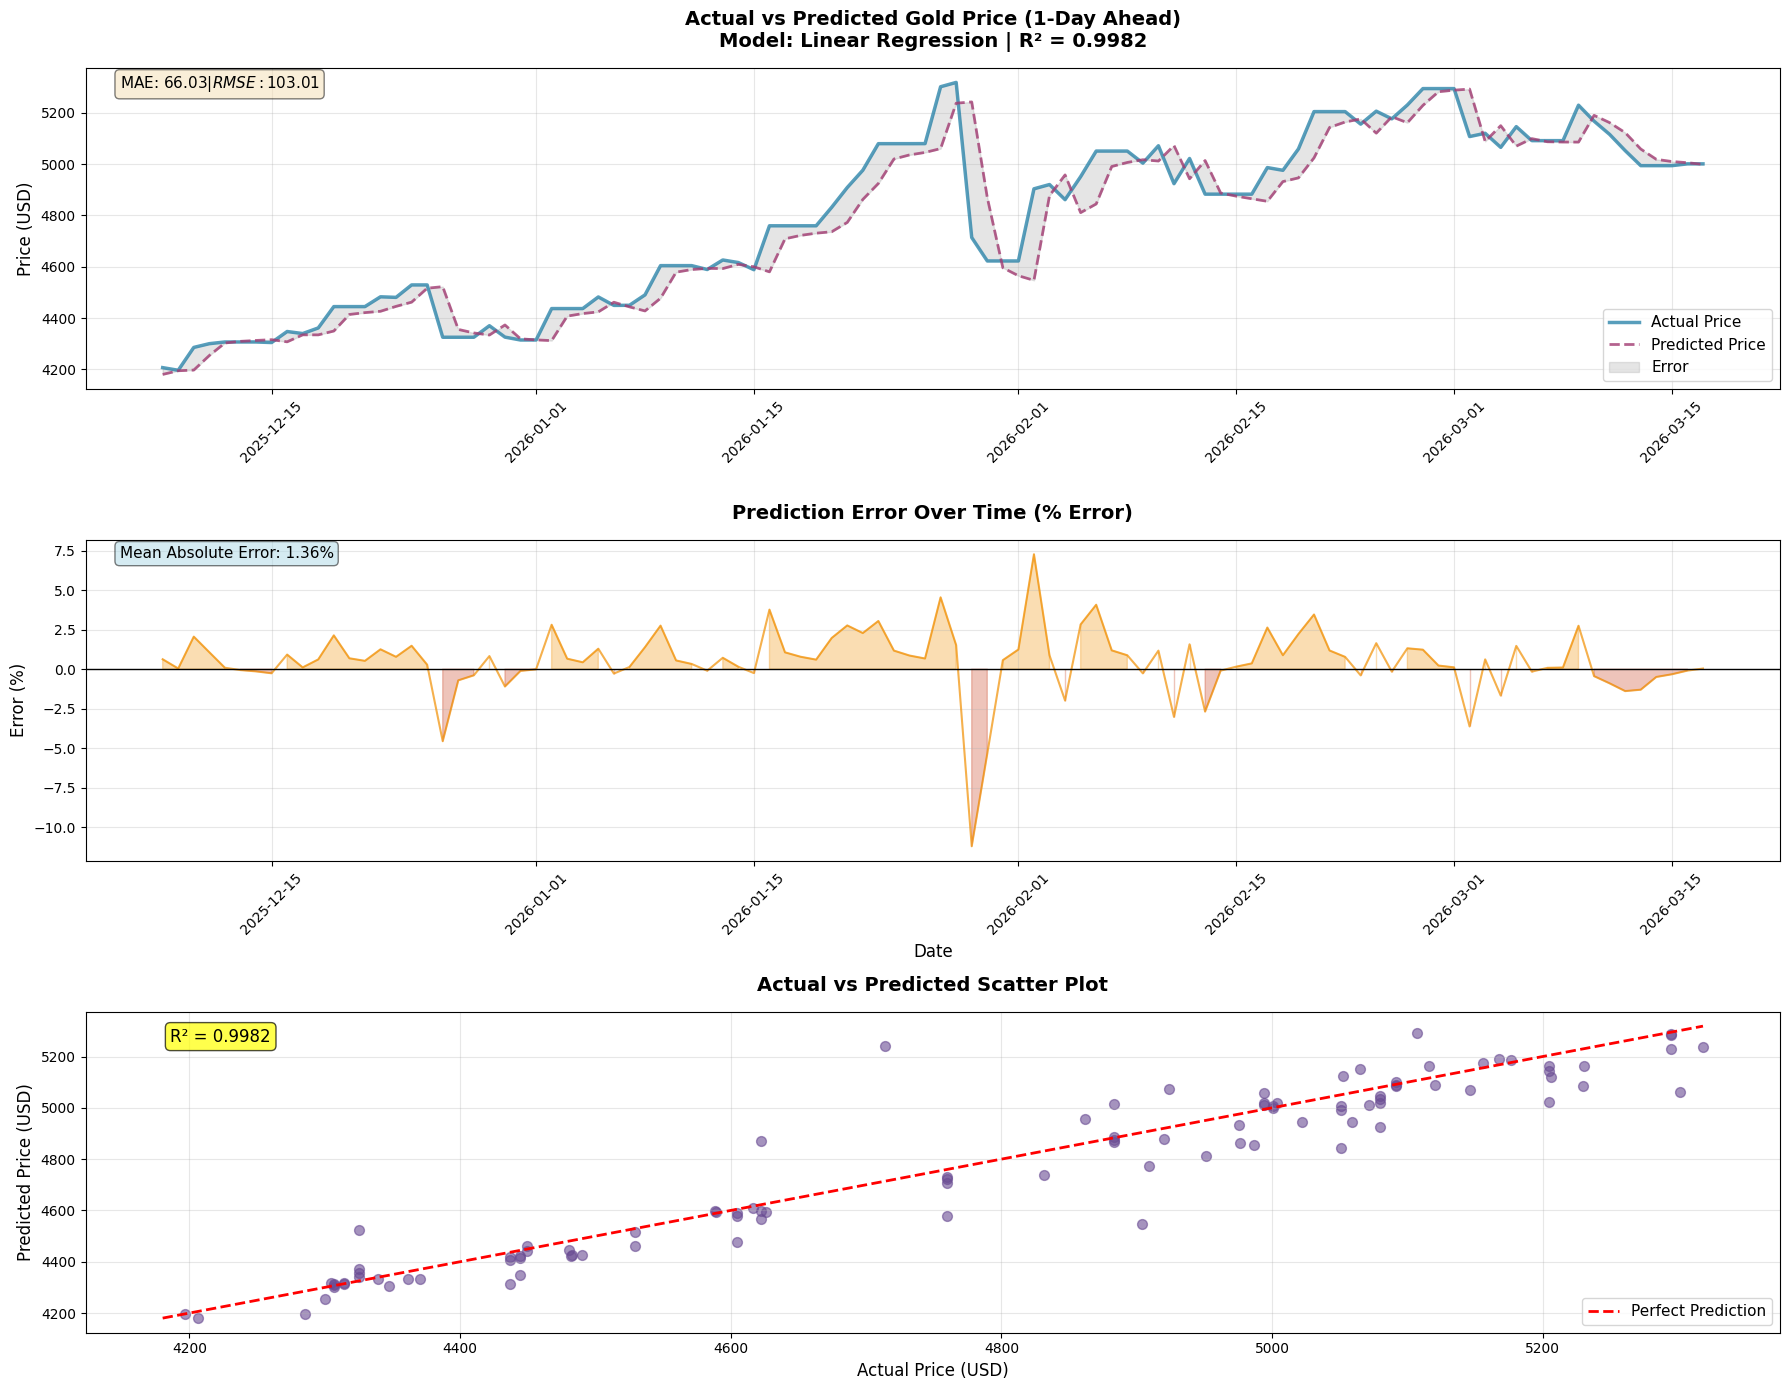

In [ ]:
# Main prediction chart - Actual vs Predicted
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1. Actual vs Predicted Price
ax1 = axes[0]
ax1.plot(dates_1d, actual_1d, label='Actual Price', color='#2E86AB', linewidth=2.5, alpha=0.8)
ax1.plot(dates_1d, pred_1d, label='Predicted Price', color='#A23B72', linewidth=2, linestyle='--', alpha=0.8)
ax1.fill_between(dates_1d, actual_1d, pred_1d, alpha=0.2, color='gray', label='Error')
ax1.set_title(f'Actual vs Predicted Gold Price (1-Day Ahead)\nModel: {best_combined["model_name"]} | R² = {best_combined["test_r2"]:.4f}',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Calculate and display error metrics
mae_plot = mean_absolute_error(actual_1d, pred_1d)
rmse_plot = np.sqrt(mean_squared_error(actual_1d, pred_1d))
error_text = f'MAE: ${mae_plot:.2f} | RMSE: ${rmse_plot:.2f}'
ax1.text(0.02, 0.98, error_text, transform=ax1.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Prediction Error Over Time
ax2 = axes[1]
error = actual_1d - pred_1d
error_pct = (error / actual_1d) * 100
ax2.plot(dates_1d, error_pct, color='#F18F01', linewidth=1.5, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.fill_between(dates_1d, error_pct, 0, alpha=0.3, color='#F18F01', where=(error_pct >= 0))
ax2.fill_between(dates_1d, error_pct, 0, alpha=0.3, color='#C73E1D', where=(error_pct < 0))
ax2.set_title('Prediction Error Over Time (% Error)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Error (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
mean_error = np.mean(np.abs(error_pct))
ax2.text(0.02, 0.98, f'Mean Absolute Error: {mean_error:.2f}%', transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 3. Scatter Plot: Actual vs Predicted
ax3 = axes[2]
ax3.scatter(actual_1d, pred_1d, alpha=0.6, s=50, color='#6A4C93')
min_price = min(min(actual_1d), min(pred_1d))
max_price = max(max(actual_1d), max(pred_1d))
ax3.plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Price (USD)', fontsize=12)
ax3.set_ylabel('Predicted Price (USD)', fontsize=12)
ax3.set_title('Actual vs Predicted Scatter Plot', fontsize=14, fontweight='bold', pad=15)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Add R² score to scatter plot
ax3.text(0.05, 0.95, f'R² = {best_combined["test_r2"]:.4f}', transform=ax3.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

Generating future predictions for next 30 days...



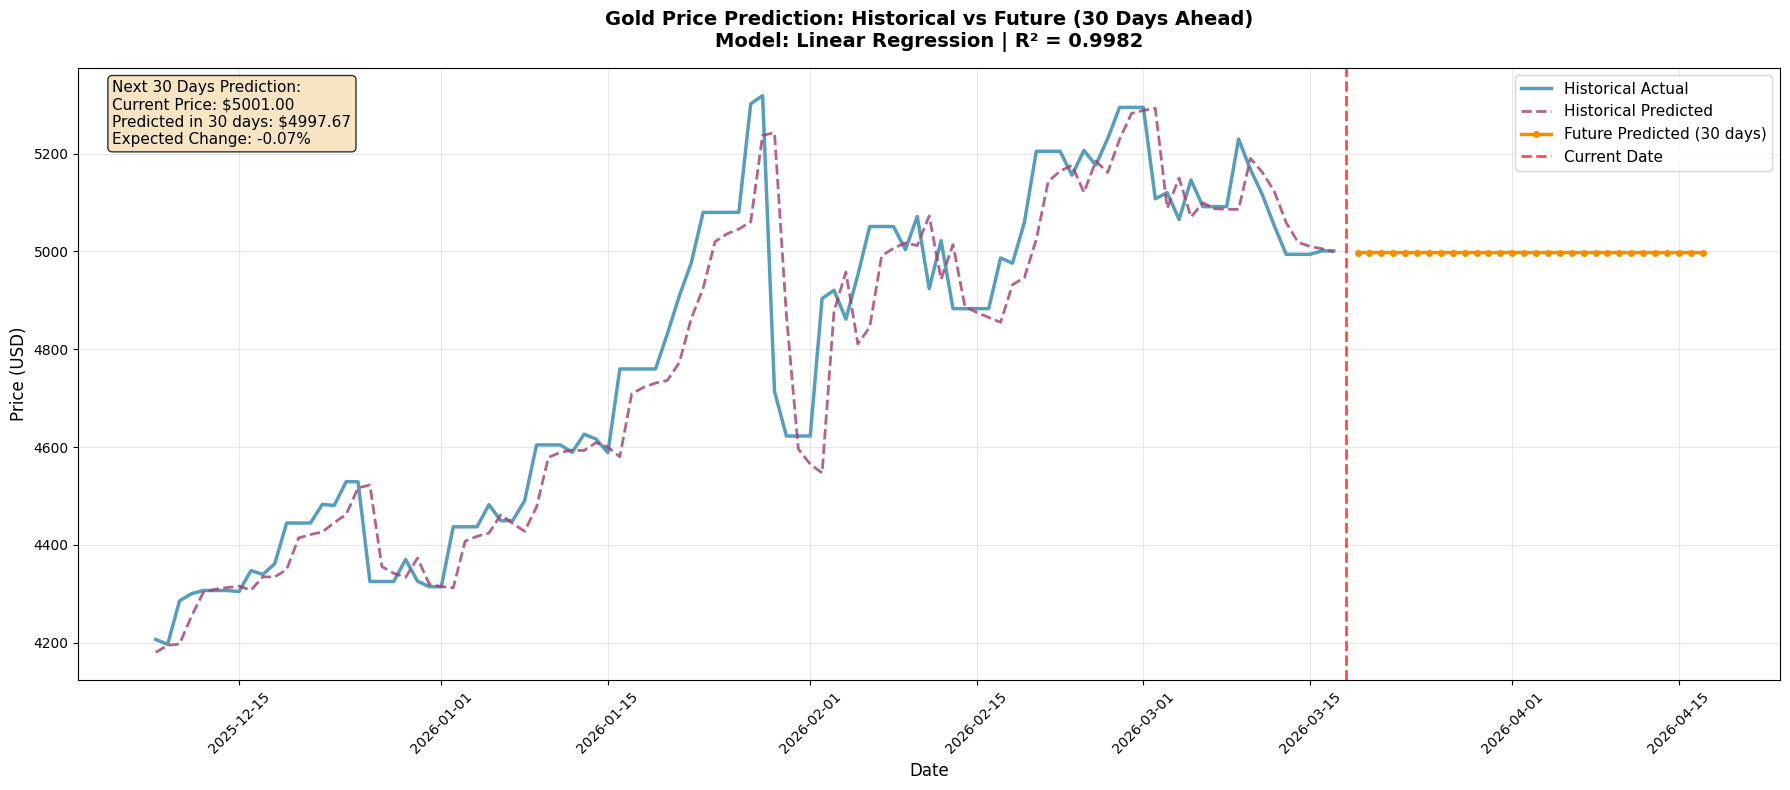

Current Price: $5001.00
Predicted Price in 30 days: $4997.67
Expected Change: -0.07%


In [ ]:
# Future prediction chart (next 30 days)
print("Generating future predictions for next 30 days...\n")

# Use best model to predict future
best_model_obj = best_combined['model']
best_scaler = best_combined['scaler']

# Get last available data point
last_data = combined_data[combined_features].iloc[-1:].values
last_date = combined_data.index[-1]

# Generate 30-day ahead predictions
future_predictions = []
future_dates = []
current_data = last_data.copy()

for day in range(30):
    # Scale and predict
    current_scaled = best_scaler.transform(current_data)
    next_pred = best_model_obj.predict(current_scaled)[0]
    future_predictions.append(next_pred)

    # Create next date
    next_date = last_date + pd.Timedelta(days=day+1)
    future_dates.append(next_date)

    # Update current_data for next iteration (simplified - using predicted close)
    # In reality, you'd need to update all features
    current_data[0][3] = next_pred  # Update Close price

future_predictions = np.array(future_predictions)

# Plot historical + future predictions
fig, ax = plt.subplots(figsize=(18, 8))

# Historical actual prices (last 100 days)
historical_dates = dates_1d[-100:]
historical_actual = actual_1d[-100:]

# Historical predictions
historical_pred = pred_1d[-100:]

# Plot
ax.plot(historical_dates, historical_actual, label='Historical Actual', color='#2E86AB', linewidth=2.5, alpha=0.8)
ax.plot(historical_dates, historical_pred, label='Historical Predicted', color='#A23B72', linewidth=2, linestyle='--', alpha=0.8)
ax.plot(future_dates, future_predictions, label='Future Predicted (30 days)', color='#F18F01', linewidth=2.5, linestyle='-', marker='o', markersize=4)

# Add vertical line to separate historical and future
ax.axvline(x=last_date, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Current Date')

ax.set_title(f'Gold Price Prediction: Historical vs Future (30 Days Ahead)\nModel: {best_combined["model_name"]} | R² = {best_combined["test_r2"]:.4f}',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Add text box with prediction info
pred_text = f'Next 30 Days Prediction:\n'
pred_text += f'Current Price: ${historical_actual[-1]:.2f}\n'
pred_text += f'Predicted in 30 days: ${future_predictions[-1]:.2f}\n'
pred_text += f'Expected Change: {((future_predictions[-1] - historical_actual[-1]) / historical_actual[-1] * 100):.2f}%'

ax.text(0.02, 0.98, pred_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Current Price: ${historical_actual[-1]:.2f}")
print(f"Predicted Price in 30 days: ${future_predictions[-1]:.2f}")
print(f"Expected Change: {((future_predictions[-1] - historical_actual[-1]) / historical_actual[-1] * 100):.2f}%")

Train rows: 1507 | Test rows: 31 | Features: 155

=== Persistence Baseline (yesterday close = today) ===
MAE : 43.9130
RMSE: 65.3934

=== Random Forest (skforecast) ===
MAE : 47.1417
RMSE: 61.1270

=== Deep Learning Baseline: MLP (sklearn) ===
MAE : 48.1029
RMSE: 61.5561

=== Deep Learning: Keras (TensorFlow) ===
MAE : 45.9072
RMSE: 63.4594

=== Model Comparison (lower is better) ===
                       Model        MAE       RMSE
1  RandomForest (skforecast)  47.141728  61.127045
2              MLP (sklearn)  48.102881  61.556086
3   Keras Dense (TensorFlow)  45.907226  63.459359
0     Persistence (baseline)  43.912976  65.393362


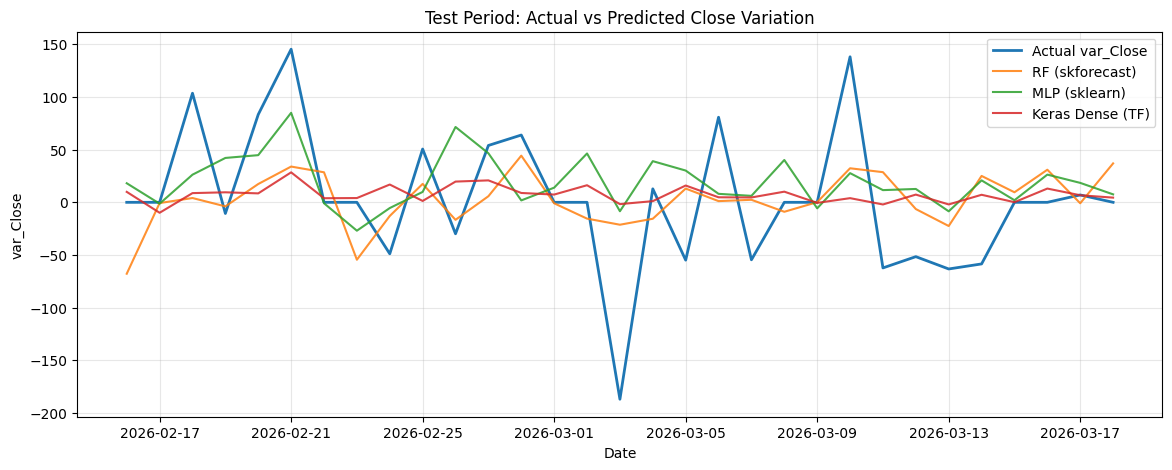

In [ ]:
# Build train/test matrices
exog_cols = df.columns[df.columns.str.contains('var_Prev')].tolist()

X_train = df.loc[train_start:train_end, exog_cols].copy()
y_train = df.loc[train_start:train_end, 'var_Close'].copy()
X_test = df.loc[test_start:test_end, exog_cols].copy()
y_test = df.loc[test_start:test_end, 'var_Close'].copy()

# Align & drop NaNs
train_mask = ~(X_train.isna().any(axis=1) | y_train.isna())
test_mask = ~(X_test.isna().any(axis=1) | y_test.isna())
X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]
X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)} | Features: {len(exog_cols)}")

results = []

# =========================
# 0) Persistence baseline (no change: yesterday close = today close)
# =========================
pred_persistence = np.zeros(len(y_test))  # var_Close = 0 (no change)
mae_pers = mean_absolute_error(y_test, pred_persistence)
rmse_pers = np.sqrt(mean_squared_error(y_test, pred_persistence))
results.append({"Model": "Persistence (baseline)", "MAE": float(mae_pers), "RMSE": float(rmse_pers)})
print("\n=== Persistence Baseline (yesterday close = today) ===")
print(f"MAE : {mae_pers:.4f}")
print(f"RMSE: {rmse_pers:.4f}")

# =========================
# 1) Random Forest (skforecast)
# =========================
print("\n=== Random Forest (skforecast) ===")

forecaster_rf = ForecasterAutoreg(
    regressor=RandomForestRegressor(
        n_estimators=500,
        random_state=123,
        n_jobs=-1
    ),
    lags=30
)

forecaster_rf.fit(y=y_train, exog=X_train)
pred_rf = forecaster_rf.predict(steps=len(y_test), exog=X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
results.append({"Model": "RandomForest (skforecast)", "MAE": float(mae_rf), "RMSE": float(rmse_rf)})

print(f"MAE : {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")

# =========================
# 2) Deep Learning baseline: MLP (sklearn)
# =========================
print("\n=== Deep Learning Baseline: MLP (sklearn) ===")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    random_state=123,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

mlp.fit(X_train_scaled, y_train.values)
pred_mlp = mlp.predict(X_test_scaled)

mae_mlp = mean_absolute_error(y_test.values, pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test.values, pred_mlp))
results.append({"Model": "MLP (sklearn)", "MAE": float(mae_mlp), "RMSE": float(rmse_mlp)})

print(f"MAE : {mae_mlp:.4f}")
print(f"RMSE: {rmse_mlp:.4f}")

# =========================
# 3) Optional: Deep Learning with TensorFlow/Keras (if installed)
# =========================
pred_keras = None
if tf is not None and keras is not None:
    print("\n=== Deep Learning: Keras (TensorFlow) ===")
    tf.random.set_seed(123)

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1)
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled, y_train.values,
        validation_split=0.1,
        epochs=300,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    pred_keras = model.predict(X_test_scaled, verbose=0).reshape(-1)
    mae_keras = mean_absolute_error(y_test.values, pred_keras)
    rmse_keras = np.sqrt(mean_squared_error(y_test.values, pred_keras))
    results.append({"Model": "Keras Dense (TensorFlow)", "MAE": float(mae_keras), "RMSE": float(rmse_keras)})

    print(f"MAE : {mae_keras:.4f}")
    print(f"RMSE: {rmse_keras:.4f}")
else:
    print("\n(TensorFlow not detected. If you want Keras deep learning, install it first: pip install tensorflow)")

# =========================
# Summary table
# =========================
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Model Comparison (lower is better) ===")
print(results_df)

# =========================
# Plot comparison on test period
# =========================
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Actual var_Close', linewidth=2)
plt.plot(y_test.index, pred_rf.values, label='RF (skforecast)', linewidth=1.5, alpha=0.85)
plt.plot(y_test.index, pred_mlp, label='MLP (sklearn)', linewidth=1.5, alpha=0.85)
if pred_keras is not None:
    plt.plot(y_test.index, pred_keras, label='Keras Dense (TF)', linewidth=1.5, alpha=0.85)
plt.title('Test Period: Actual vs Predicted Close Variation')
plt.xlabel('Date')
plt.ylabel('var_Close')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## LSTM (Long Short-Term Memory) Model

Uses the same `df['Close']` already loaded above — no extra import or data reload needed.
- MinMaxScaler, lookback = 60, architecture: LSTM(128) → LSTM(64) → Dense(25) → Dense(1)
- EarlyStopping (patience=5) to avoid overfitting
- Compared alongside RF / MLP / XGBoost above

In [ ]:
# ── LSTM: Data Prep (uses same date-based split as other models) ─────────────
from sklearn.preprocessing import MinMaxScaler as _MMS
from tensorflow.keras.models import Sequential as _Seq
from tensorflow.keras.layers import Dense as _Dense, LSTM as _LSTM
from tensorflow.keras.callbacks import EarlyStopping as _ES, ModelCheckpoint as _MC
import numpy as _np

lstm_data = df[['Close']].copy()
# Use same date-based split as tree/skforecast models (train_start, train_end, test_start, test_end)
lstm_train_df = lstm_data.loc[train_start:train_end]
lstm_test_df  = lstm_data.loc[test_start:test_end]
dataset_train = lstm_train_df.values
dataset_test  = lstm_test_df.values

# CRITICAL: Fit scaler ONLY on training data to avoid data leakage
lstm_scaler = _MMS(feature_range=(0, 1))
train_scaled = lstm_scaler.fit_transform(dataset_train)
test_scaled  = lstm_scaler.transform(dataset_test)

LOOKBACK = 60
x_train_lstm, y_train_lstm = [], []
for i in range(LOOKBACK, len(train_scaled)):
    x_train_lstm.append(train_scaled[i-LOOKBACK:i, 0])
    y_train_lstm.append(train_scaled[i, 0])

x_train_lstm = _np.array(x_train_lstm).reshape(-1, LOOKBACK, 1)
y_train_lstm = _np.array(y_train_lstm)
print(f"LSTM train period: {train_start} to {train_end} | samples: {len(x_train_lstm)}")
print(f"LSTM test period:  {test_start} to {test_end}")
print(f"x_train_lstm shape: {x_train_lstm.shape}")

LSTM train period: 2022-01-01 to 2026-02-15 | samples: 1447
LSTM test period:  2026-02-16 to 2026-03-18
x_train_lstm shape: (1447, 60, 1)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint

lstm_model = Sequential()
lstm_model.add(LSTM(128, return_sequences=True, input_shape=(x_train_lstm.shape[1], 1)))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mean_squared_error")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history_lstm = lstm_model.fit(
    x_train_lstm, y_train_lstm,
    batch_size=32,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 1.5138e-04 - val_loss: 0.0013
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 1.3770e-04 - val_loss: 0.0013
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 1.3959e-04 - val_loss: 0.0013
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 1.3824e-04 - val_loss: 0.0013
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 1.3194e-04 - val_loss: 0.0012
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 1.2710e-04 - val_loss: 0.0012
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 1.2432e-04 - val_loss: 0.0012
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 1.2237e-04 - val_loss: 0.0012
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 1.2077e-04 - val_loss: 0.0012
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 1.1898e-04 - val_loss: 0.0012
Epoch 12

In [ ]:
# ── LSTM: Test & Predict (same date-based test period as other models) ────────
# Build test sequences: need LOOKBACK values before each test point (use train tail + test)
combined_scaled = _np.vstack([train_scaled, test_scaled])
x_test_lstm = []
for i in range(len(train_scaled), len(combined_scaled)):
    x_test_lstm.append(combined_scaled[i-LOOKBACK:i, 0])

x_test_lstm = _np.array(x_test_lstm).reshape(-1, LOOKBACK, 1)
y_test_lstm = dataset_test  # actual Close values for test period

lstm_predictions = lstm_model.predict(x_test_lstm)
lstm_predictions = lstm_scaler.inverse_transform(lstm_predictions)

lstm_rmse = _np.sqrt(_np.mean((lstm_predictions.flatten() - y_test_lstm.flatten()) ** 2))
print(f"LSTM RMSE: ${lstm_rmse:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
LSTM RMSE: $65.5924


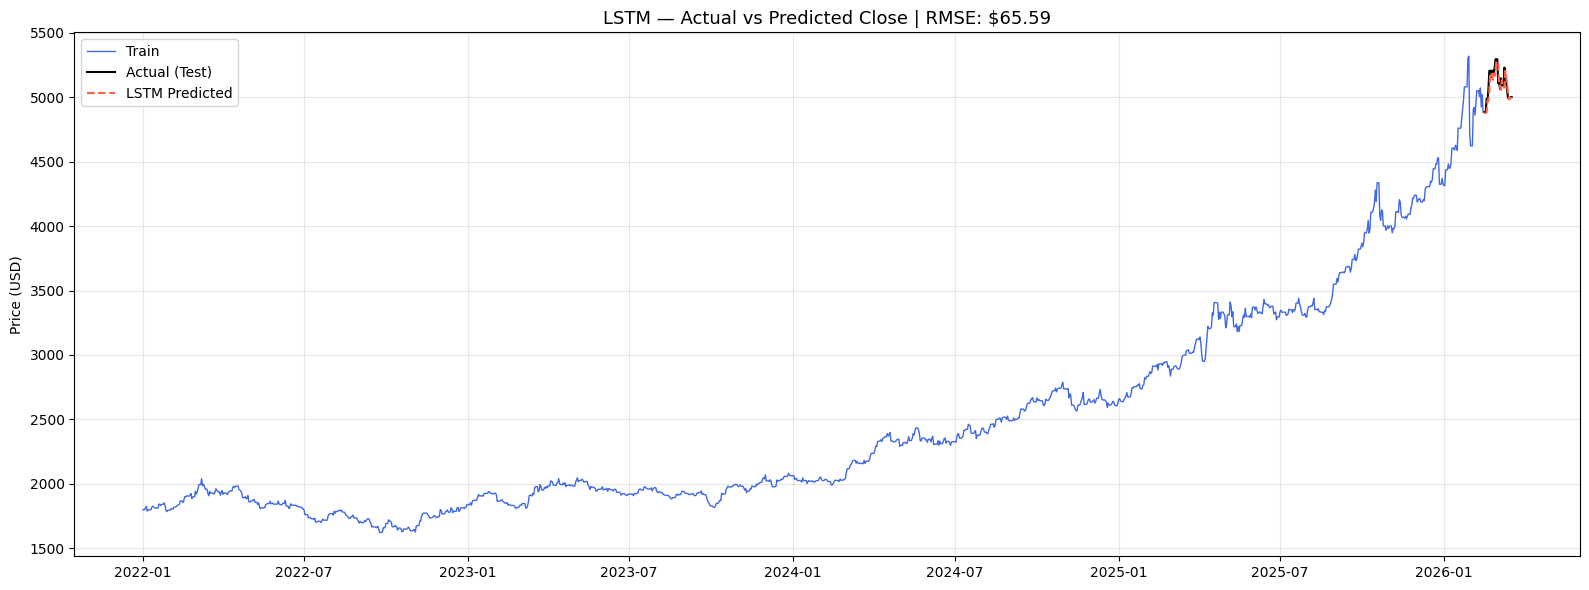

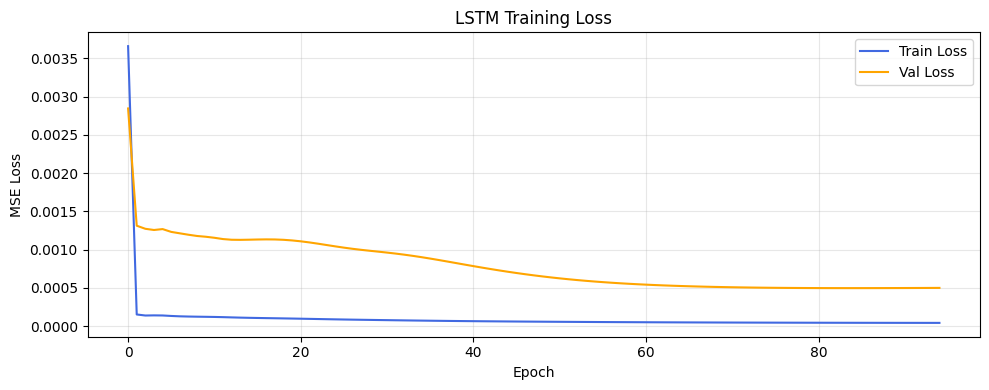

In [ ]:
# ── LSTM: Plot ──────────────────────────────────────────────────────────────
lstm_train_plot = lstm_train_df
lstm_valid = lstm_test_df.copy()
lstm_valid['Predictions'] = lstm_predictions.flatten()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(lstm_train_plot.index, lstm_train_plot['Close'],
        label='Train', color='royalblue', linewidth=1)
ax.plot(lstm_valid.index, lstm_valid['Close'],
        label='Actual (Test)', color='black', linewidth=1.5)
ax.plot(lstm_valid.index, lstm_valid['Predictions'],
        label='LSTM Predicted', color='tomato', linewidth=1.5, linestyle='--')
ax.set_title(f'LSTM — Actual vs Predicted Close | RMSE: ${lstm_rmse:.2f}', fontsize=13)
ax.set_ylabel('Price (USD)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Plot training loss (from history returned by fit)
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(history_lstm.history['loss'], color='royalblue', label='Train Loss')
if 'val_loss' in history_lstm.history:
    ax2.plot(history_lstm.history['val_loss'], color='orange', label='Val Loss')
ax2.set_title('LSTM Training Loss'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

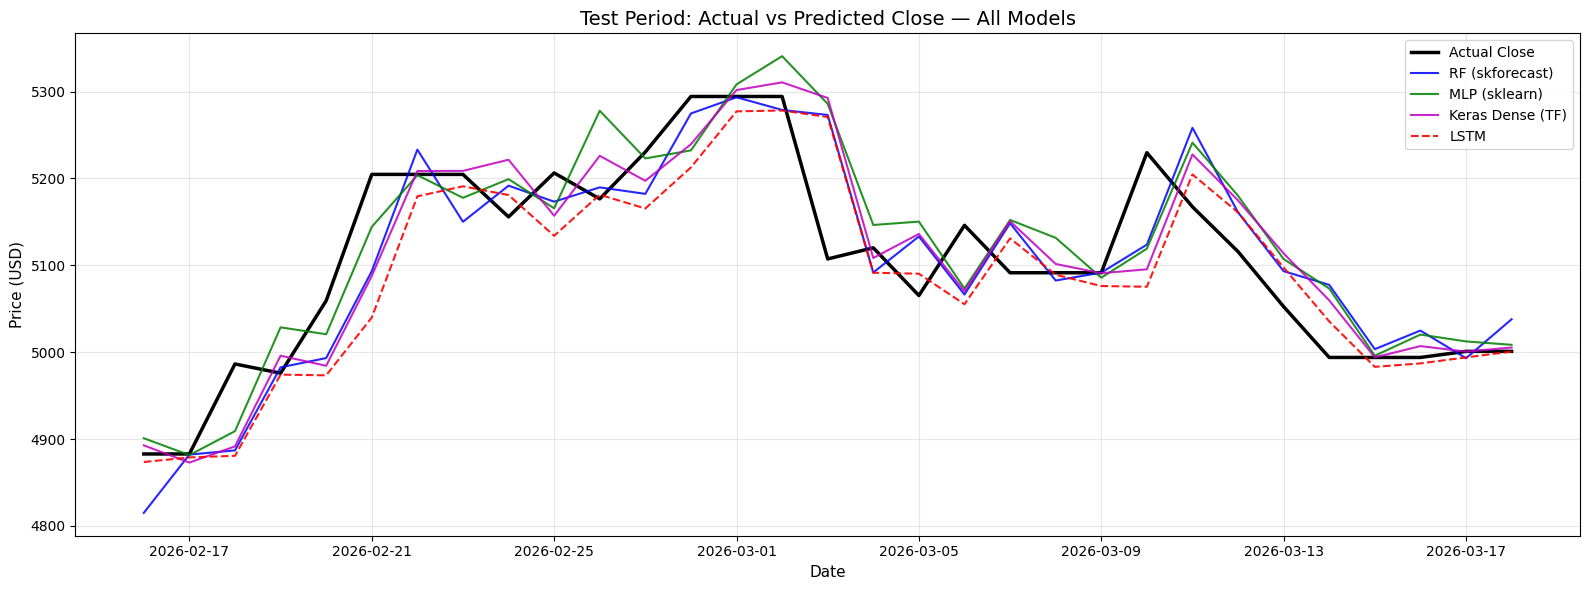

In [ ]:
# ── Combined Chart: Actual vs Predicted — All Models (Test Period) ────────────
# RF, MLP, Keras predict var_Close → Close = prev_Close + var_pred
# LSTM predicts Close directly

dates = y_test.index
prev = df.loc[dates, 'prev_Close'].values
actual = df.loc[dates, 'Close'].values

# Align LSTM to dates
n = len(dates)
lstm_pred = lstm_predictions.flatten()
lstm_dates = lstm_test_df.index
if len(lstm_dates) != n:
    lstm_pred = lstm_pred[:n] if len(lstm_pred) >= n else np.pad(lstm_pred, (0, n - len(lstm_pred)), constant_values=np.nan)
    lstm_dates = dates

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dates, actual, 'k-', linewidth=2.5, label='Actual Close')
ax.plot(dates, prev + pred_rf.values, 'b-', linewidth=1.5, alpha=0.85, label='RF (skforecast)')
ax.plot(dates, prev + pred_mlp, 'g-', linewidth=1.5, alpha=0.85, label='MLP (sklearn)')
if pred_keras is not None:
    ax.plot(dates, prev + pred_keras, 'm-', linewidth=1.5, alpha=0.85, label='Keras Dense (TF)')
ax.plot(lstm_dates, lstm_pred, 'r--', linewidth=1.5, alpha=0.9, label='LSTM')
ax.set_title('Test Period: Actual vs Predicted Close — All Models', fontsize=14)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── LSTM: Next-Day Prediction ────────────────────────────────────────────────
last_close_lstm = float(df['Close'].iloc[-1])
# Use last 60 closes, scale with train-fitted scaler (no leakage)
last_60_closes  = df['Close'].iloc[-LOOKBACK:].values.reshape(-1, 1)
last_60_scaled  = lstm_scaler.transform(last_60_closes)
last_60_seq     = last_60_scaled.reshape(1, LOOKBACK, 1)
next_day_scaled = lstm_model.predict(last_60_seq, verbose=0)
next_day_lstm   = float(lstm_scaler.inverse_transform(next_day_scaled)[0, 0])
implied_ret     = (next_day_lstm - last_close_lstm) / last_close_lstm * 100

print("=== LSTM Next-Day Prediction ===")
print(f"Last close      : ${last_close_lstm:.2f}")
print(f"Predicted close : ${next_day_lstm:.2f}")
print(f"Implied return  : {implied_ret:+.4f}%")
print(f"Direction       : {'BULLISH' if next_day_lstm > last_close_lstm else 'BEARISH'}")
print(f"Data through    : {df.index[-1].date()}")

=== LSTM Next-Day Prediction ===
Last close      : $5001.00
Predicted close : $4998.67
Implied return  : -0.0465%
Direction       : BEARISH
Data through    : 2026-03-18


## Next-Day Gold Price Prediction — All Models

Predicts tomorrow's close using every available model in this notebook:
Baseline · Forecaster (DecisionTree/skforecast) · Best sklearn (Combined) · Advanced models (RF/GB/MLP/XGBoost) · LSTM

  [Forecaster] skipped: To make predictions `exog` must start one step ahead of `last_window`.
    `last_window` ends at : 2026-02-15 00:00:00.
    `exog` starts at : 2026-03-18 00:00:00.
    Expected index : 2026-02-16 00:00:00.
  NEXT-DAY GOLD PRICE PREDICTION — ALL MODELS
  Data as of  : 2026-03-18
  Predicting  : 2026-03-19
  Last close  : $5001.00
  Model                                   Pred. Close     Return       Signal
  ----------------------------------------------------------------------------
  Baseline (Last Close)                  $   5001.00     +0.000%   → FLAT
  Best sklearn (Linear Regression)       $   4997.59     -0.068%   ↓ BEARISH
  Random Forest (200 trees)              $   1958.00    -60.848%   ↓ BEARISH
  Gradient Boosting (200 trees)          $   1934.81    -61.312%   ↓ BEARISH
  MLP Neural Network                     $   5059.29     +1.166%   ↑ BULLISH
  XGBoost                                $   1926.65    -61.475%   ↓ BEARISH
  LSTM (60-day lookback)     

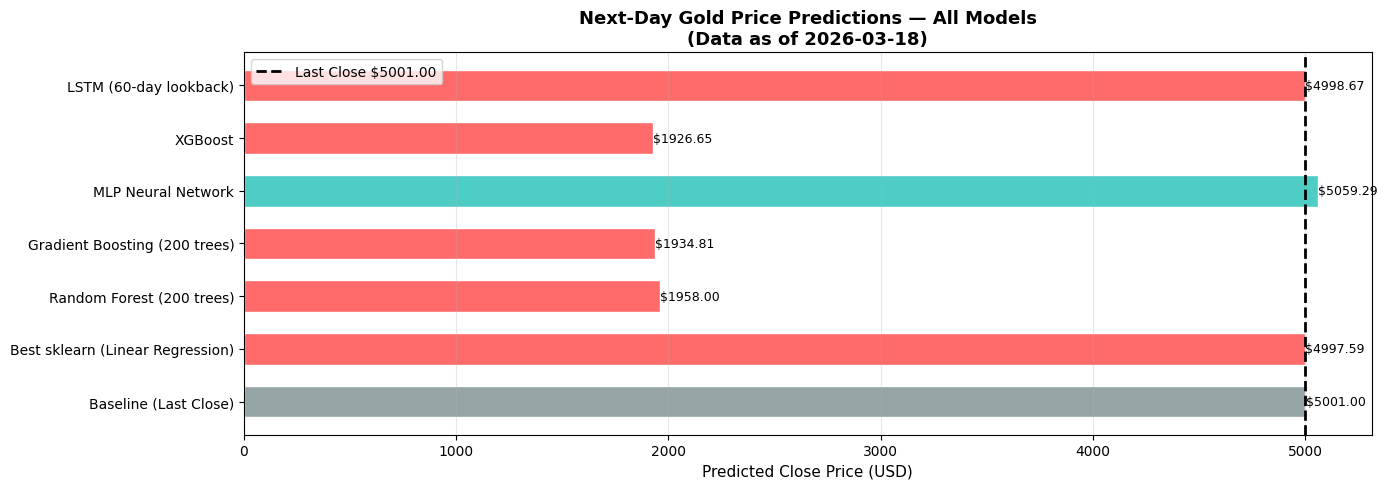


  Note: For informational purposes only. Not financial advice.
  Tip : Re-run from top daily to use the latest market data.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ── Determine last known close price (try both data sources) ─────────────────
last_close, last_date = None, None
try:
    last_close = float(combined_data['Close'].iloc[-1])
    last_date  = combined_data.index[-1]
except Exception:
    pass
try:
    _lc_lstm = float(data['close'].iloc[-1])
    _ld_lstm = data.index[-1]
    if last_close is None:
        last_close, last_date = _lc_lstm, _ld_lstm
except Exception:
    pass

if last_close is None:
    print("ERROR: Could not find last close price. Make sure data cells ran successfully.")
else:
    preds = []   # list of dicts: {Model, Predicted Close, Implied Return (%), Direction}

    def _record(name, pred_close):
        ret = (pred_close - last_close) / last_close * 100
        direction = '↑ BULLISH' if pred_close > last_close else ('↓ BEARISH' if pred_close < last_close else '→ FLAT')
        preds.append({'Model': name, 'Predicted Close': pred_close,
                      'Implied Return (%)': ret, 'Direction': direction})

    # ── 1. Baseline (naive: tomorrow = today) ────────────────────────────────
    _record('Baseline (Last Close)', last_close)

    # ── 2. skforecast Forecaster (DecisionTree / tuned) ──────────────────────
    try:
        _exog_cols = df.columns[df.columns.str.contains('var_Prev')].tolist()
        _latest_exog = df[_exog_cols].iloc[-1:].fillna(0)
        _var_pred = forecaster.predict(steps=1, exog=_latest_exog)[0]
        _record('Forecaster (DecisionTree)', last_close + _var_pred)
    except Exception as e:
        print(f"  [Forecaster] skipped: {e}")

    # ── 3. Best sklearn model (Combined dataset) ─────────────────────────────
    try:
        _feats = combined_data[combined_features].iloc[-1:]
        _clean = np.nan_to_num(_feats.values, nan=0.0, posinf=0.0, neginf=0.0)
        _scaled = best_combined['scaler'].transform(_clean)
        _pred = float(best_combined['model'].predict(_scaled)[0])
        _record(f"Best sklearn ({best_combined['model_name']})", _pred)
    except Exception as e:
        print(f"  [Best sklearn] skipped: {e}")

    # ── 4. Advanced models (RF, Gradient Boosting, MLP, XGBoost) ─────────────
    try:
        _last_feat = np.nan_to_num(
            combined_data[combined_features].iloc[-1:].values,
            nan=0.0, posinf=0.0, neginf=0.0
        )
        for _res in advanced_results:
            try:
                _sc  = _res.get('scaler')
                _mod = _res.get('model')
                if _sc is None or _mod is None:
                    continue
                _pred_adv = float(_mod.predict(_sc.transform(_last_feat))[0])
                _record(_res['model_name'], _pred_adv)
            except Exception as e:
                print(f"  [{_res.get('model_name','?')}] skipped: {e}")
    except Exception as e:
        print(f"  [Advanced models] skipped: {e}")

    # ── 5. LSTM (60-day sequence lookback) ────────────────────────────────────
    try:
        _last60_closes = df['Close'].iloc[-LOOKBACK:].values.reshape(-1, 1)
        _last60_scaled = lstm_scaler.transform(_last60_closes)
        _last60_seq   = _last60_scaled.reshape(1, LOOKBACK, 1)
        _pred_sc      = lstm_model.predict(_last60_seq, verbose=0)
        _pred_lstm    = float(lstm_scaler.inverse_transform(_pred_sc)[0, 0])
        _record('LSTM (60-day lookback)', _pred_lstm)
    except Exception as e:
        print(f"  [LSTM] skipped: {e}")

    # ── Print table ───────────────────────────────────────────────────────────
    _next_trading = last_date + timedelta(days=1)
    print("=" * 72)
    print("  NEXT-DAY GOLD PRICE PREDICTION — ALL MODELS")
    print(f"  Data as of  : {last_date.date()}")
    print(f"  Predicting  : {_next_trading.date()}")
    print(f"  Last close  : ${last_close:.2f}")
    print("=" * 72)
    print(f"  {'Model':<38} {'Pred. Close':>12} {'Return':>10} {'Signal':>12}")
    print("  " + "-" * 76)
    for p in preds:
        print(f"  {p['Model']:<38} ${p['Predicted Close']:>10.2f}   {p['Implied Return (%)']:>+8.3f}%   {p['Direction']}")

    # ── Bar chart: predicted closes ───────────────────────────────────────────
    _labels = [p['Model'] for p in preds]
    _values = [p['Predicted Close'] for p in preds]
    _colors = ['#4ECDC4' if v > last_close else ('#FF6B6B' if v < last_close else '#95A5A6')
               for v in _values]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.barh(_labels, _values, color=_colors, edgecolor='white', height=0.6)
    ax.axvline(x=last_close, color='black', linewidth=2, linestyle='--', label=f'Last Close ${last_close:.2f}')
    for bar, val in zip(bars, _values):
        ax.text(val + abs(val) * 0.0005, bar.get_y() + bar.get_height()/2,
                f'${val:.2f}', va='center', fontsize=9)
    ax.set_title(f'Next-Day Gold Price Predictions — All Models\n(Data as of {last_date.date()})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Close Price (USD)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('nextday_all_models.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("\n  Note: For informational purposes only. Not financial advice.")
    print("  Tip : Re-run from top daily to use the latest market data.")

## Section 7: Macro Indicators + Sentiment Analysis (Standalone)

This section adds macroeconomic context and news sentiment — **run independently** without re-running previous cells.

| Indicator | Ticker | Relationship to Gold |
|-----------|--------|----------------------|
| **DXY** — US Dollar Index | `DX-Y.NYB` | Inverse: stronger USD → lower gold |
| **US10Y** — 10-Year Treasury Yield | `^TNX` | Inverse: higher rates → lower gold |
| **CPI** — Consumer Price Index | FRED `CPIAUCSL` | Positive: higher inflation → higher gold |
| **VIX** — CBOE Volatility Index | `^VIX` | Positive: market fear → safe-haven gold demand |

> **Note:** These cells are self-contained. They re-download their own data and do not depend on variables from earlier cells.

In [ ]:
# Install additional packages needed for this section
# (yfinance is already installed; pandas_datareader handles FRED CPI; vaderSentiment for NLP)
!pip install pandas_datareader vaderSentiment --quiet
print("Packages ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
Packages ready.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

START = "2009-01-01"
END   = datetime.today().strftime('%Y-%m-%d')

print("Downloading macro indicators from Yahoo Finance...")

_tickers = {
    'XAU'   : 'GC=F',       # Gold Futures (close proxy)
    'DXY'   : 'DX-Y.NYB',   # US Dollar Index
    'US10Y' : '^TNX',        # 10-Year Treasury Yield
    'VIX'   : '^VIX',        # CBOE Volatility Index
}

def _extract_close(raw, name):
    """
    Safely extract a 1-D close price Series from a yfinance DataFrame.
    Handles both old (flat columns) and new (MultiIndex columns) yfinance behaviour.
    """
    col = raw['Close'] if 'Close' in raw.columns else raw.iloc[:, 0]
    # Newer yfinance returns a DataFrame with ticker as second-level column
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
    col = col.squeeze()          # make absolutely sure it's 1-D
    idx = col.index
    if hasattr(idx, 'tz') and idx.tz is not None:
        idx = idx.tz_localize(None)
    return pd.Series(col.values, index=idx, name=name)

_frames = {}
for name, ticker in _tickers.items():
    try:
        raw = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
        s = _extract_close(raw, name)
        _frames[name] = s
        print(f"  {name:6s} ({ticker:12s}) : {len(s)} rows  "
              f"[{s.index[0].date()} → {s.index[-1].date()}]")
    except Exception as e:
        print(f"  WARNING: {name} ({ticker}) failed — {e}")

# Build DataFrame by concatenating Series (index-safe)
macro_raw = pd.concat(_frames, axis=1)
macro_raw.index = pd.to_datetime(macro_raw.index)
macro_raw = macro_raw.sort_index().ffill()

print(f"\nCombined macro DataFrame: {macro_raw.shape[0]} rows x {macro_raw.shape[1]} cols")
macro_raw.tail(3)

  XAU    (GC=F        ) : 4333 rows  [2009-01-02 → 2026-03-26]
  DXY    (DX-Y.NYB    ) : 4335 rows  [2009-01-02 → 2026-03-26]
  US10Y  (^TNX        ) : 4332 rows  [2009-01-02 → 2026-03-26]
  VIX    (^VIX        ) : 4334 rows  [2009-01-02 → 2026-03-26]

Combined macro DataFrame: 4338 rows x 4 cols


,XAU,DXY,US10Y,VIX
Date,,,,
2026-03-24,4399.299805,99.430000,4.392,26.950001
2026-03-25,4549.799805,99.599998,4.328,25.330000
2026-03-26,4375.500000,99.900002,4.416,27.440001


In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

START = "2009-01-01"

cpi_daily = None

# --- Attempt 1: pandas_datareader via FRED (no API key required) ---
try:
    import pandas_datareader.data as web
    print("Fetching CPI (CPIAUCSL) from FRED...")
    cpi_monthly = web.DataReader('CPIAUCSL', 'fred', start=START, end=datetime.today())
    cpi_monthly.index = pd.to_datetime(cpi_monthly.index).tz_localize(None)
    # Interpolate monthly → daily
    cpi_daily_full = cpi_monthly.resample('D').interpolate(method='linear')
    cpi_daily = cpi_daily_full['CPIAUCSL'].rename('CPI')
    print(f"  CPI loaded: {len(cpi_monthly)} monthly records → {len(cpi_daily)} daily (interpolated)")
    print(cpi_monthly.tail(3))

except Exception as e1:
    print(f"  FRED attempt failed: {e1}")

    # --- Attempt 2: 5-Year Breakeven Inflation Rate as proxy ---
    try:
        import yfinance as yf
        print("  Trying T5YIE (5Y Breakeven Inflation) as CPI proxy via yfinance...")
        raw = yf.download('T5YIE', start=START, end=datetime.today().strftime('%Y-%m-%d'),
                          auto_adjust=True, progress=False)
        s = raw['Close'].copy()
        s.index = pd.to_datetime(s.index).tz_localize(None)
        cpi_daily = s.rename('CPI')
        print(f"  CPI proxy loaded: {len(cpi_daily)} rows")
    except Exception as e2:
        print(f"  Fallback also failed: {e2}")
        print("  CPI will be omitted from the macro dataset.")

if cpi_daily is not None:
    print(f"\nCPI series ready — last value: {cpi_daily.iloc[-1]:.4f}  (date: {cpi_daily.index[-1].date()})")

Fetching CPI (CPIAUCSL) from FRED...
  CPI loaded: 206 monthly records → 6241 daily (interpolated)
            CPIAUCSL
DATE                
2025-12-01   326.031
2026-01-01   326.588
2026-02-01   327.460

CPI series ready — last value: 327.4600  (date: 2026-02-01)


Macro dataset: 4338 rows  |  Columns: ['XAU', 'DXY', 'US10Y', 'VIX', 'CPI']
                    XAU        DXY  US10Y        VIX         CPI
Date                                                            
2026-03-24  4399.299805  99.430000  4.392  26.950001  327.403742
2026-03-25  4549.799805  99.599998  4.328  25.330000  327.403742
2026-03-26  4375.500000  99.900002  4.416  27.440001  327.403742


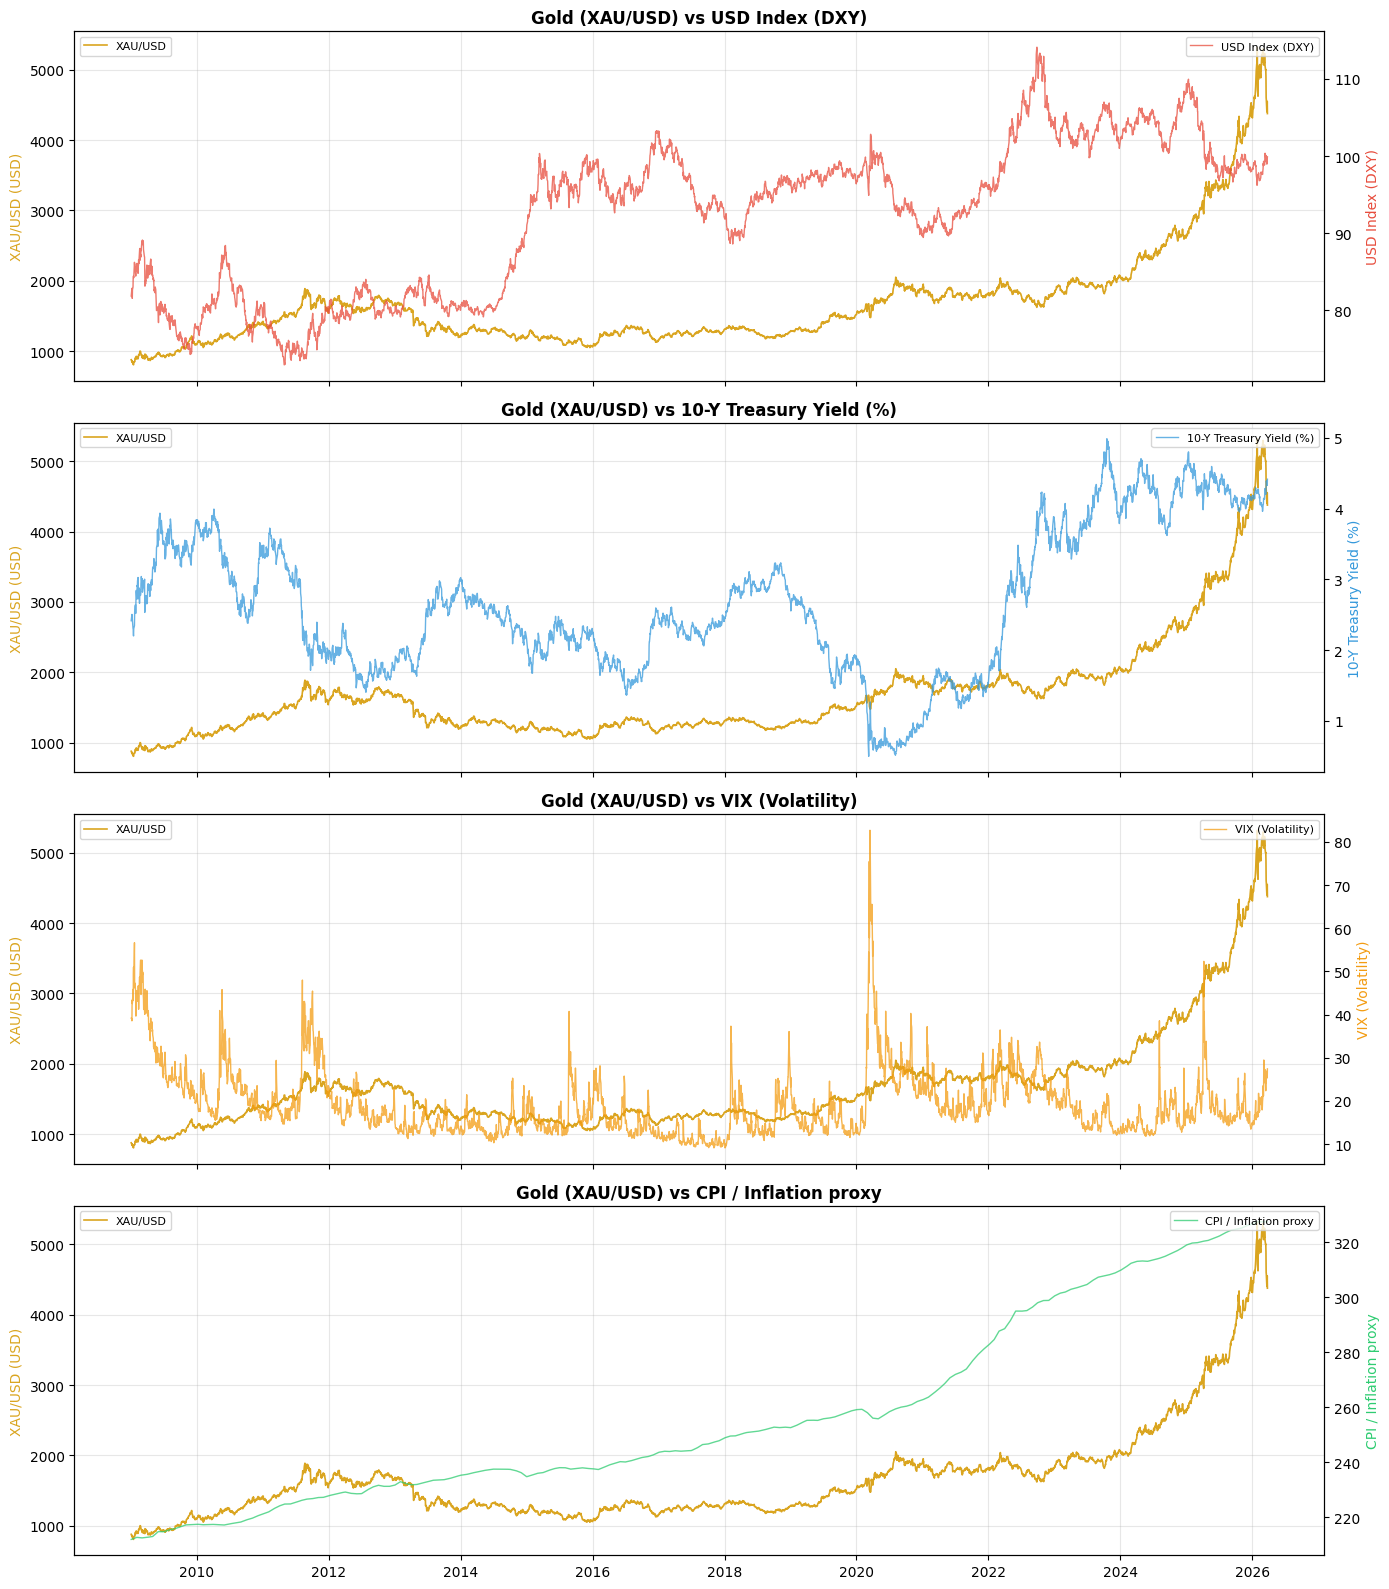

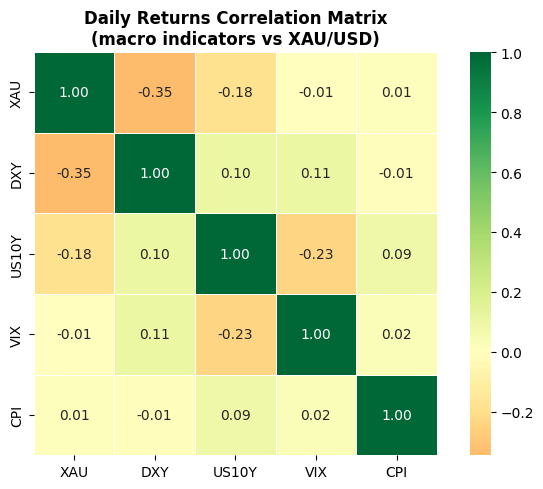

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Merge CPI into macro_raw ────────────────────────────────────────────────
macro_full = macro_raw.copy()

if cpi_daily is not None:
    macro_full['CPI'] = cpi_daily
    macro_full = macro_full.ffill()

macro_full = macro_full.dropna(subset=['XAU', 'DXY', 'US10Y', 'VIX'])

print(f"Macro dataset: {len(macro_full)} rows  |  Columns: {list(macro_full.columns)}")
print(macro_full.tail(3))

# ── 4-panel chart: XAU vs each indicator ────────────────────────────────────
indicators = [c for c in ['DXY', 'US10Y', 'VIX', 'CPI'] if c in macro_full.columns]
colors     = {'DXY': '#e74c3c', 'US10Y': '#3498db', 'VIX': '#f39c12', 'CPI': '#2ecc71'}
labels     = {
    'DXY'  : 'USD Index (DXY)',
    'US10Y': '10-Y Treasury Yield (%)',
    'VIX'  : 'VIX (Volatility)',
    'CPI'  : 'CPI / Inflation proxy',
}

n = len(indicators)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, ind in zip(axes, indicators):
    ax2 = ax.twinx()
    ax.plot(macro_full.index, macro_full['XAU'],
            color='goldenrod', linewidth=1.2, label='XAU/USD')
    ax2.plot(macro_full.index, macro_full[ind],
             color=colors[ind], linewidth=1, alpha=0.75, label=labels[ind])
    ax.set_ylabel('XAU/USD (USD)', color='goldenrod', fontsize=10)
    ax2.set_ylabel(labels[ind], color=colors[ind], fontsize=10)
    ax.set_title(f'Gold (XAU/USD) vs {labels[ind]}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('macro_vs_gold.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Correlation heatmap (daily returns) ─────────────────────────────────────
try:
    import seaborn as sns
    corr = macro_full.pct_change().corr()
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                linewidths=0.5, square=True)
    plt.title('Daily Returns Correlation Matrix\n(macro indicators vs XAU/USD)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('macro_correlation_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
except ImportError:
    print("seaborn not found — skipping heatmap. Run: pip install seaborn")

### Sentiment Analysis — Gold News Headlines

Uses **VADER** (Valence Aware Dictionary and sEntiment Reasoner) — a rule-based NLP model tuned for financial/social-media text. No API key required.

- Compound score: `+1.0` = most positive, `-1.0` = most negative
- Signal threshold: `> 0.05` → Bullish, `< -0.05` → Bearish

  Fetched 10 news items from GC=F
  Extracted 10 usable headlines

  GOLD SENTIMENT ANALYSIS  (10 headlines)
  Average Compound Score : +0.087
  Market Signal          : BULLISH
                                                                                  Headline  Compound
                                             Gold Rises But Can’t Finish the Week Positive    0.7096
Gold price today, Friday, March 27: Gold strengthens after President Trump extends Hormuz     0.5423
LaFleur Minerals Files a PEA Supporting Restart of Gold Production at the Beacon Gold Mill    0.4404
                                              Business Lookahead: Gauging the war's impact    0.0000
                           Forte Minerals Moving To Advance Alto Ruri Gold Project in Peru    0.0000
              Citigroup Moves Into $1 Trillion London Gold Market With Heathrow Vault Plan    0.0000
                              Gold Heads for First Weekly Gain Since Middle East War Began   -0.1280
TSX Closer: Th

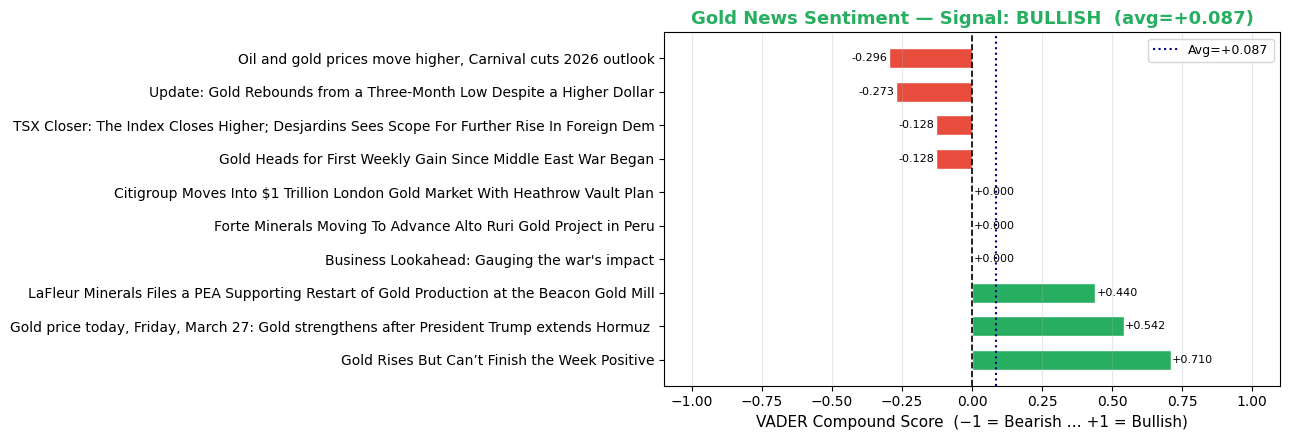

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── VADER sentiment ──────────────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    _vader_ok = True
except ImportError:
    print("vaderSentiment not installed. Run: pip install vaderSentiment")
    _vader_ok = False

def _extract_title(item):
    """
    Extract headline text from a yfinance news item.
    yfinance >= 0.2.x changed the structure — title may be nested inside
    'content' dict. Try multiple known key paths before giving up.
    """
    # Flat structure (older yfinance)
    for key in ('title', 'Title', 'headline', 'Headline'):
        if item.get(key):
            return str(item[key])
    # Nested structure: item['content']['title']  (newer yfinance)
    content = item.get('content') or {}
    if isinstance(content, dict):
        for key in ('title', 'Title', 'headline'):
            if content.get(key):
                return str(content[key])
    return ''

_SAMPLE_HEADLINES = [
    'Gold rises as dollar weakens amid inflation fears',
    'Fed signals interest rate cuts, gold surges to record high',
    'Gold drops sharply after strong US jobs report',
    'Investors flock to safe-haven gold amid geopolitical tensions',
    'Dollar strength weighs on gold prices',
    'Gold futures near all-time highs on recession fears',
    'Central banks increase gold reserves for the fifth straight year',
    'XAU/USD retreats as risk appetite improves on trade deal hopes',
    'Gold demand rises in Asia as emerging-market currencies weaken',
    'Inflation data beats expectations; gold rallies above $3000',
]

if _vader_ok:
    analyzer = SentimentIntensityAnalyzer()

    # ── Fetch Gold news headlines via yfinance ───────────────────────────────
    raw_news = []
    for _sym in ['GC=F', 'GLD', 'IAU']:
        try:
            _n = yf.Ticker(_sym).news or []
            if _n:
                raw_news.extend(_n)
                print(f"  Fetched {len(_n)} news items from {_sym}")
                break
        except Exception as e:
            print(f"  {_sym}: {e}")

    # Extract titles with multi-version support
    titles = [_extract_title(item) for item in raw_news]
    titles = [t for t in titles if t]

    if not titles:
        print("  No titles extracted from live news — using sample headlines.")
        titles = _SAMPLE_HEADLINES
    else:
        print(f"  Extracted {len(titles)} usable headlines")

    # ── Score each headline ──────────────────────────────────────────────────
    results = []
    for title in titles[:25]:
        sc = analyzer.polarity_scores(title)
        results.append({
            'Headline' : title[:90],
            'Compound' : sc['compound'],
            'Positive' : sc['pos'],
            'Negative' : sc['neg'],
            'Neutral'  : sc['neu'],
        })

    sent_df = pd.DataFrame(results)
    if 'Compound' not in sent_df.columns:
        sent_df = pd.DataFrame(columns=['Headline', 'Compound', 'Positive', 'Negative', 'Neutral'])

    sent_df = sent_df.sort_values('Compound', ascending=False)
    avg = sent_df['Compound'].mean() if not sent_df.empty else 0.0

    # ── Overall signal ───────────────────────────────────────────────────────
    if avg > 0.05:
        signal, sig_color = 'BULLISH', '#27ae60'
    elif avg < -0.05:
        signal, sig_color = 'BEARISH', '#e74c3c'
    else:
        signal, sig_color = 'NEUTRAL', '#f39c12'

    print(f"\n{'='*65}")
    print(f"  GOLD SENTIMENT ANALYSIS  ({len(sent_df)} headlines)")
    print(f"  Average Compound Score : {avg:+.3f}")
    print(f"  Market Signal          : {signal}")
    print(f"{'='*65}")
    if not sent_df.empty:
        print(sent_df[['Headline', 'Compound']].to_string(index=False))

    # ── Horizontal bar chart ─────────────────────────────────────────────────
    if not sent_df.empty:
        fig, ax = plt.subplots(figsize=(13, max(4, len(sent_df) * 0.45)))
        bar_colors = [('#27ae60' if v > 0.05 else ('#e74c3c' if v < -0.05 else '#95a5a6'))
                      for v in sent_df['Compound']]
        bars = ax.barh(sent_df['Headline'], sent_df['Compound'],
                       color=bar_colors, edgecolor='white', height=0.6)
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
        ax.axvline(avg, color='navy', linewidth=1.5, linestyle=':', label=f'Avg={avg:+.3f}')
        for bar, val in zip(bars, sent_df['Compound']):
            ax.text(val + (0.005 if val >= 0 else -0.005),
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:+.3f}', va='center', ha=('left' if val >= 0 else 'right'), fontsize=8)
        ax.set_xlabel('VADER Compound Score  (−1 = Bearish … +1 = Bullish)', fontsize=11)
        ax.set_title(f'Gold News Sentiment — Signal: {signal}  (avg={avg:+.3f})',
                     fontsize=13, fontweight='bold', color=sig_color)
        ax.legend(fontsize=9)
        ax.set_xlim(-1.1, 1.1)
        ax.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig('gold_sentiment.png', dpi=120, bbox_inches='tight')
        plt.show()

### Macro-Enhanced Prediction Model

Trains **Random Forest** and **Gradient Boosting** regressors using Gold OHLC + DXY + US10Y + VIX + CPI as features, then predicts tomorrow's close.

Using macro_full: (4338, 5)
Train: 3453 rows | Test: 864 rows | Features: 15
Features: ['XAU_lag1', 'XAU_lag5', 'XAU_lag10', 'XAU_ma7', 'XAU_ma21', 'XAU_ret1', 'XAU_ret5', 'DXY', 'DXY_lag1', 'DXY_ret1', 'US10Y', 'US10Y_lag1', 'VIX', 'VIX_lag1', 'CPI']

Model                                   MAE       RMSE
------------------------------------------------------
Random Forest  (macro-enhanced)  $   772.66 $  1171.23
Gradient Boost (macro-enhanced)  $   784.80 $  1180.68

  MACRO-ENHANCED NEXT-DAY PREDICTION
  Last close  (2026-03-25) : $4549.80
  RF  Macro prediction             : $1950.69  (-57.126%)
  GB  Macro prediction             : $1940.01  (-57.360%)


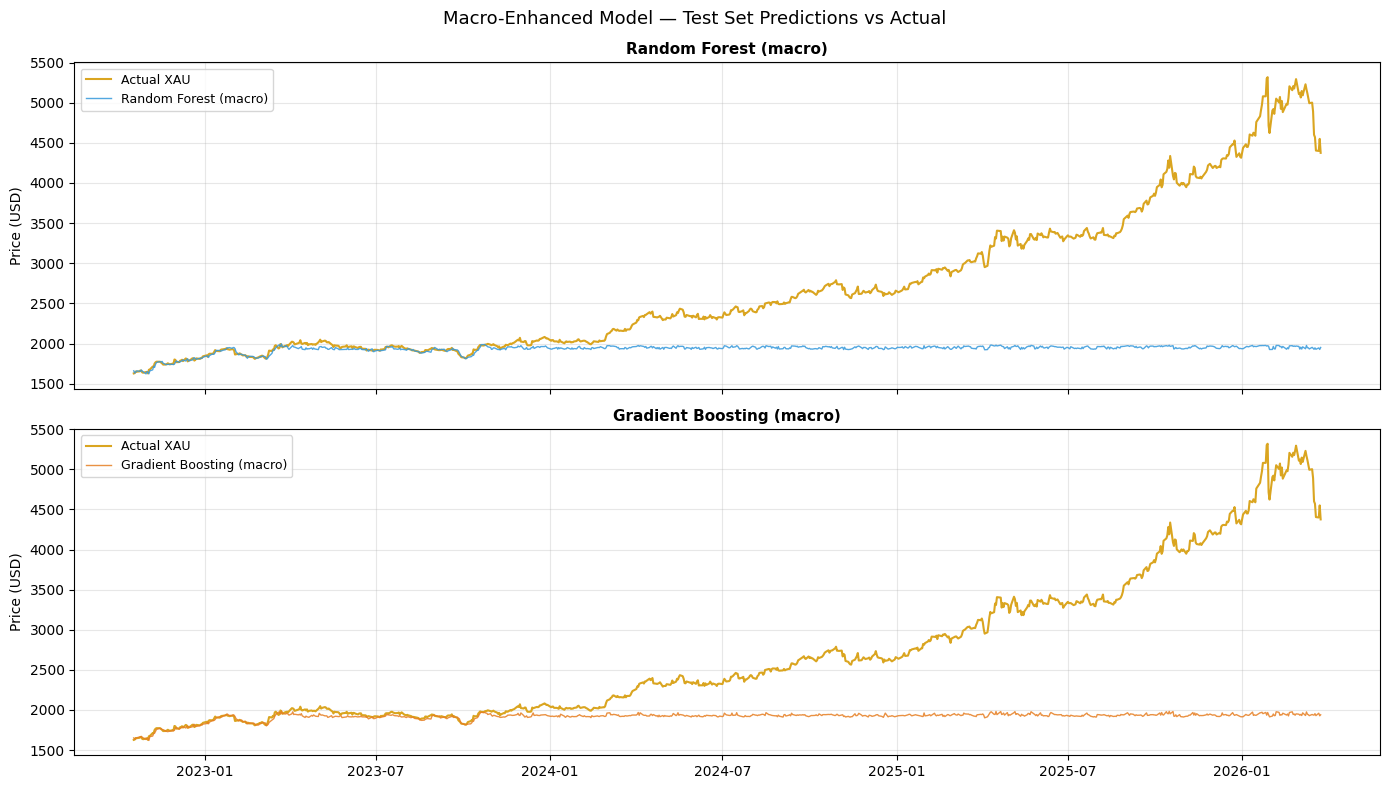

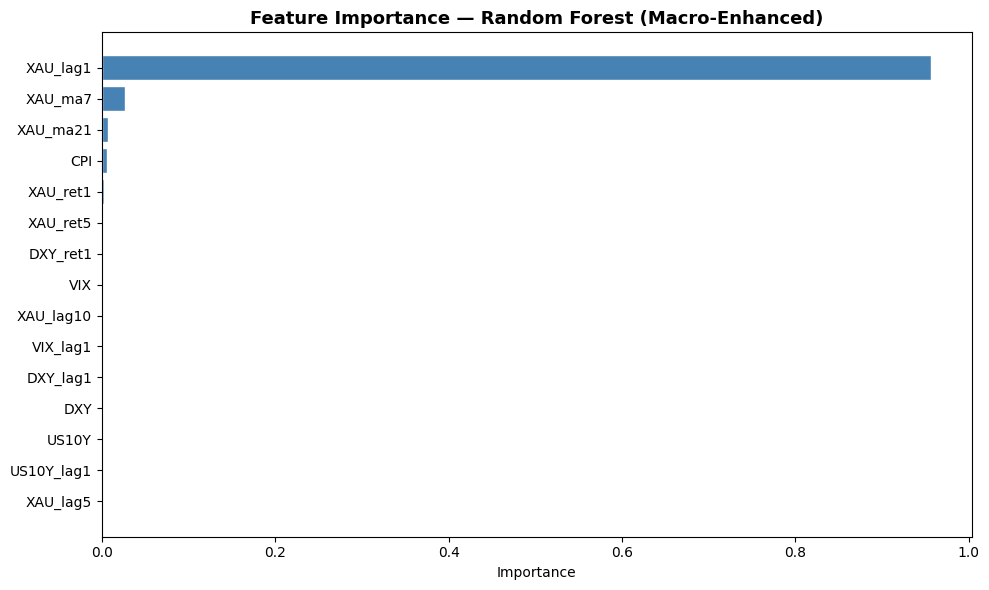


Note: For informational purposes only. Not financial advice.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Require macro_full from earlier cell ─────────────────────────────────────
try:
    _ = macro_full
    print(f"Using macro_full: {macro_full.shape}")
except NameError:
    raise RuntimeError("Run the 'Download Macro Indicators' cells first (cells 59–61).")

# ── Feature engineering ──────────────────────────────────────────────────────
df_m = macro_full.copy().dropna(subset=['XAU', 'DXY', 'US10Y', 'VIX'])

df_m['XAU_lag1']   = df_m['XAU'].shift(1)
df_m['XAU_lag5']   = df_m['XAU'].shift(5)
df_m['XAU_lag10']  = df_m['XAU'].shift(10)
df_m['XAU_ma7']    = df_m['XAU'].rolling(7).mean()
df_m['XAU_ma21']   = df_m['XAU'].rolling(21).mean()
df_m['XAU_ret1']   = df_m['XAU'].pct_change(1)
df_m['XAU_ret5']   = df_m['XAU'].pct_change(5)
df_m['DXY_lag1']   = df_m['DXY'].shift(1)
df_m['DXY_ret1']   = df_m['DXY'].pct_change(1)
df_m['VIX_lag1']   = df_m['VIX'].shift(1)
df_m['US10Y_lag1'] = df_m['US10Y'].shift(1)
df_m['target']     = df_m['XAU'].shift(-1)   # next-day close

df_m = df_m.dropna()

base_feats = [
    'XAU_lag1', 'XAU_lag5', 'XAU_lag10',
    'XAU_ma7', 'XAU_ma21',
    'XAU_ret1', 'XAU_ret5',
    'DXY', 'DXY_lag1', 'DXY_ret1',
    'US10Y', 'US10Y_lag1',
    'VIX', 'VIX_lag1',
]
if 'CPI' in df_m.columns:
    base_feats.append('CPI')

X = df_m[base_feats].values
y = df_m['target'].values

# ── Train / test split (80 / 20, time-ordered) ───────────────────────────────
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

print(f"Train: {split} rows | Test: {len(X_test)} rows | Features: {len(base_feats)}")
print(f"Features: {base_feats}\n")

# ── Fit models ────────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=300, max_depth=None,
                           random_state=42, n_jobs=-1)
rf.fit(X_tr_s, y_train)

gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                               max_depth=4, random_state=42)
gb.fit(X_tr_s, y_train)

rf_preds = rf.predict(X_te_s)
gb_preds = gb.predict(X_te_s)

rf_mae = mean_absolute_error(y_test, rf_preds)
gb_mae = mean_absolute_error(y_test, gb_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))

print(f"{'Model':<32} {'MAE':>10} {'RMSE':>10}")
print('-' * 54)
print(f"{'Random Forest  (macro-enhanced)':<32} ${rf_mae:>9.2f} ${rf_rmse:>9.2f}")
print(f"{'Gradient Boost (macro-enhanced)':<32} ${gb_mae:>9.2f} ${gb_rmse:>9.2f}")

# ── Next-day prediction ───────────────────────────────────────────────────────
last_row   = df_m[base_feats].iloc[-1:].values
last_row_s = scaler.transform(last_row)
last_close = float(df_m['XAU'].iloc[-1])
last_date  = df_m.index[-1]

rf_next = float(rf.predict(last_row_s)[0])
gb_next = float(gb.predict(last_row_s)[0])

print(f"\n{'='*54}")
print(f"  MACRO-ENHANCED NEXT-DAY PREDICTION")
print(f"  Last close  ({last_date.date()}) : ${last_close:.2f}")
print(f"  RF  Macro prediction             : ${rf_next:.2f}  ({(rf_next-last_close)/last_close*100:+.3f}%)")
print(f"  GB  Macro prediction             : ${gb_next:.2f}  ({(gb_next-last_close)/last_close*100:+.3f}%)")
print(f"{'='*54}")

# ── Prediction vs Actual chart ────────────────────────────────────────────────
test_dates = df_m.index[split:]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, preds, name, col in zip(
        axes,
        [rf_preds, gb_preds],
        ['Random Forest (macro)', 'Gradient Boosting (macro)'],
        ['#3498db', '#e67e22']):
    ax.plot(test_dates, y_test, color='goldenrod', linewidth=1.5, label='Actual XAU')
    ax.plot(test_dates, preds,  color=col,         linewidth=1,   alpha=0.85, label=name)
    ax.set_ylabel('Price (USD)')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle('Macro-Enhanced Model — Test Set Predictions vs Actual', fontsize=13)
plt.tight_layout()
plt.savefig('macro_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Feature importance ────────────────────────────────────────────────────────
imp_df = pd.DataFrame({'Feature': base_feats, 'Importance': rf.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'],
         color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest (Macro-Enhanced)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('macro_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nNote: For informational purposes only. Not financial advice.")